In [1]:
# (Full file — minimal edits for FixUp init + block-wise LR)
import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a single linear
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        # self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        self.flash = False
        if not self.flash:
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True
            )
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v  # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = y.transpose(1, 2).contiguous().view(B, T, C)  # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):
    """
    Transformer block WITH Pre-LayerNorm.
    Each residual branch is scaled by a fixed factor alpha = 1/sqrt(n_layer).
    """

    def __init__(self, config):
        super().__init__()
        self.attn = CausalSelfAttention(config)
        self.mlp = MLP(config)

        # --- Added: Pre-LayerNorm for attention and MLP ---
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.ln_2 = nn.LayerNorm(config.n_embd)

        # fixed scaling factor (not learnable)
        self.scale = 1.0 /  math.sqrt(config.n_layer)

    def forward(self, x):
        # Pre-LN attention
        x = x + self.scale  * self.attn(self.ln_1(x))

        # Pre-LN MLP
        x = x + self.scale * self.mlp(self.ln_2(x))

        return x


@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304  # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 6
    n_head: int = 8
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True  # True: bias in Linears, False: faster slightly


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        # transformer modules
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            # NOTE: removed ln_f (final LayerNorm) entirely (kept that choice minimal)
        ))
        # language model head
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight tying: share token embedding and lm_head weights
        # this keeps behavior similar to original GPT implementations
        self.transformer.wte.weight = self.lm_head.weight

        # init all weights (base)
        self.apply(self._init_weights)

        # -------------------------
        # Minimal FixUp-style edits
        # 1) initialize final projection weights of residual branches with std = L**(-0.75)
        # 2) zero-init biases of final projections if present
        # This prevents the model from cancelling the fixed residual scale alpha via large initial residuals.
        # -------------------------
        L = max(1, config.n_layer)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                # FixUp-style scaled init for final projection of each branch
                torch.nn.init.normal_(p, mean=0.0, std=(L ** (-0.75)))
            if pn.endswith('c_proj.bias'):
                # zero biases for stability (if bias exists)
                with torch.no_grad():
                    p.zero_()

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params() / 1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return number of parameters. If non_embedding=True subtract position embeddings
        to match many published counts.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx: (b, t) long tensor of token indices
        targets: (b, t) long tensor for computing cross-entropy loss (optional)
        """
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device)  # shape (t)

        # token + position embeddings
        tok_emb = self.transformer.wte(idx)  # (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos)  # (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)

        # forward through transformer blocks (pre-LN)
        for block in self.transformer.h:
            x = block(x)

        # no final LayerNorm (ln_f) is applied (kept minimal per request)

        if targets is not None:
            # full logits for loss computation
            logits = self.lm_head(x)  # (b, t, vocab)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # during inference, only compute logits for last token to save compute
            logits = self.lm_head(x[:, [-1], :])  # (b, 1, vocab)
            loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        """
        Reduce block size (positional embeddings and attention mask) for memory savings.
        """
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:, :, :block_size, :block_size]

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        """
        Minimal change: use a smaller learning rate for transformer block parameters so that
        the optimizer does not trivially amplify residual branch weights and cancel the effect of alpha.
        Block params (inside transformer.h) get lr = base_lr / sqrt(L). Other params use base_lr.
        """
        L = max(1, self.config.n_layer)
        lr_block = learning_rate / math.sqrt(L)
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}

        # split parameters into block params (transformer.h.*) and others
        block_decay = []
        block_nodecay = []
        other_decay = []
        other_nodecay = []

        for n, p in param_dict.items():
            is_block = n.split('.')[0] == 'transformer' and ('.h.' in n)
            # treat bias and 1-d tensors as no-decay per common practice
            if is_block:
                if p.dim() >= 2:
                    block_decay.append(p)
                else:
                    block_nodecay.append(p)
            else:
                if p.dim() >= 2:
                    other_decay.append(p)
                else:
                    other_nodecay.append(p)

        optim_groups = [
            {'params': block_decay, 'weight_decay': weight_decay, 'lr': lr_block},
            {'params': block_nodecay, 'weight_decay': 0.0, 'lr': lr_block},
            {'params': other_decay, 'weight_decay': weight_decay, 'lr': learning_rate},
            {'params': other_nodecay, 'weight_decay': 0.0, 'lr': learning_rate},
        ]

        # choose fused AdamW when available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, eps=1e-4, **extra_args)
        print(f"using fused AdamW: {use_fused}")
        print(f"block lr: {lr_block:.3e}, other lr: {learning_rate:.3e}")
        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd // cfg.n_head, cfg.block_size
        flops_per_token = 6 * N + 12 * L * H * Q * T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        flops_achieved = flops_per_iter * (1.0 / dt)
        flops_promised = 312e12  # A100 bfloat16 peak flops ~312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        autoregressive generation: append tokens to idx max_new_tokens times
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
"""
This training script can be run both on a single gpu in debug mode,
and also in a larger training run with distributed data parallel (ddp).

To run on a single GPU, example:
$ python train.py --batch_size=32 --compile=False

To run with DDP on 4 gpus on 1 node, example:
$ torchrun --standalone --nproc_per_node=4 train.py

To run with DDP on 4 gpus across 2 nodes, example:
- Run on the first (master) node with example IP 123.456.123.456:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=0 --master_addr=123.456.123.456 --master_port=1234 train.py
- Run on the worker node:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=1 --master_addr=123.456.123.456 --master_port=1234 train.py
(If your cluster does not have Infiniband interconnect prepend NCCL_IB_DISABLE=1)
"""


import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

#from model import GPTConfig, GPT

# -----------------------------------------------------------------------------
# default config values designed to train a gpt2 (124M) on OpenWebText
# I/O
out_dir = './'
eval_interval = 200
log_interval = 1
eval_iters = 200
eval_only = False # if True, script exits right after the first eval
always_save_checkpoint = True # if True, always save a checkpoint after each eval
init_from = 'scratch' # 'scratch' or 'resume' or 'gpt2*'
# wandb logging
wandb_log = False # disabled by default
wandb_project = 'ts'
wandb_run_name = 'gpt2' # 'run' + str(time.time())
# data
dataset = '/kaggle/input/wikitext/wikitext103' 
gradient_accumulation_steps = 2 # used to simulate larger batch sizes
batch_size = 16 # if gradient_accumulation_steps > 1, this is the micro-batch size  #1801350/160=11258 batches
block_size = 256
# model
n_layer = 12
n_head = 12
n_embd =  768
dropout = 0.1 # for pretraining 0 is good, for finetuning try 0.1+
bias = False # do we use bias inside LayerNorm and Linear layers?
# adamw optimizer
learning_rate = 5e-4 # max learning rate
max_iters = 10000 # total number of training iterations
weight_decay = 0.01
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
# learning rate decay settings
decay_lr = True # whether to decay the learning rate
warmup_iters = 2000 # how many steps to warm up for
lr_decay_iters = 20000 # should be ~= max_iters per Chinchilla
min_lr = 5e-6 # minimum learning rate, should be ~= learning_rate/10 per Chinchilla
# DDP settings
backend = 'nccl' # 'nccl', 'gloo', etc.
# system
device = 'cuda' # examples: 'cpu', 'cuda', 'cuda:0', 'cuda:1' etc., or try 'mps' on macbooks
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
compile = False # use PyTorch 2.0 to compile the model to be faster
# # -----------------------------------------------------------------------------
# config_keys = [k for k,v in globals().items() if not k.startswith('_') and isinstance(v, (int, float, bool, str))]
# exec(open('configurator.py').read()) # overrides from command line or config file
# config = {k: globals()[k] for k in config_keys} # will be useful for logging
# -----------------------------------------------------------------------------

# various inits, derived attributes, I/O setup
ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
if ddp:
    init_process_group(backend=backend)
    ddp_rank = int(os.environ['RANK'])
    ddp_local_rank = int(os.environ['LOCAL_RANK'])
    ddp_world_size = int(os.environ['WORLD_SIZE'])
    device = f'cuda:{ddp_local_rank}'
    torch.cuda.set_device(device)
    master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
    seed_offset = ddp_rank # each process gets a different seed
    # world_size number of processes will be training simultaneously, so we can scale
    # down the desired gradient accumulation iterations per process proportionally
    assert gradient_accumulation_steps % ddp_world_size == 0
    gradient_accumulation_steps //= ddp_world_size
else:
    # if not ddp, we are running on a single gpu, and one process
    master_process = True
    seed_offset = 0
    ddp_world_size = 1
tokens_per_iter = gradient_accumulation_steps * ddp_world_size * batch_size * block_size
print(f"tokens per iteration will be: {tokens_per_iter:,}")

if master_process:
    os.makedirs(out_dir, exist_ok=True)
torch.manual_seed(1337 + seed_offset)
torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# poor man's data loader
data_dir = os.path.join('data', dataset)
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

# init these up here, can override if init_from='resume' (i.e. from a checkpoint)
iter_num = 0
best_val_loss = 1e9

# attempt to derive vocab_size from the dataset
meta_path = os.path.join(data_dir, 'meta.pkl')
meta_vocab_size = None
if os.path.exists(meta_path):
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    meta_vocab_size = meta['vocab_size']
    print(f"found vocab_size = {meta_vocab_size} (inside {meta_path})")

# model init
model_args = dict(n_layer=n_layer, n_head=n_head, n_embd=n_embd, block_size=block_size,
                  bias=bias, vocab_size=None, dropout=dropout) # start with model_args from command line
if init_from == 'scratch':
    # init a new model from scratch
    print("Initializing a new model from scratch")
    # determine the vocab size we'll use for from-scratch training
    if meta_vocab_size is None:
        print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
    model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
elif init_from == 'resume':
    print(f"Resuming training from {out_dir}")
    # resume training from a checkpoint.
    ckpt_path = os.path.join(out_dir, 'ckpt.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    checkpoint_model_args = checkpoint['model_args']
    # force these config attributes to be equal otherwise we can't even resume training
    # the rest of the attributes (e.g. dropout) can stay as desired from command line
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = checkpoint_model_args[k]
    # create the model
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
    state_dict = checkpoint['model']
    # fix the keys of the state dictionary :(
    # honestly no idea how checkpoints sometimes get this prefix, have to debug more
    unwanted_prefix = '_orig_mod.'
    for k,v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    model.load_state_dict(state_dict)
    iter_num = checkpoint['iter_num']
    best_val_loss = checkpoint['best_val_loss']
elif init_from.startswith('gpt2'):
    print(f"Initializing from OpenAI GPT-2 weights: {init_from}")
    # initialize from OpenAI GPT-2 weights
    override_args = dict(dropout=dropout)
    model = GPT.from_pretrained(init_from, override_args)
    # read off the created config params, so we can store them into checkpoint correctly
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = getattr(model.config, k)
# crop down the model block size if desired, using model surgery
if block_size < model.config.block_size:
    model.crop_block_size(block_size)
    model_args['block_size'] = block_size # so that the checkpoint will have the right value
model.to(device)

# initialize a GradScaler. If enabled=False scaler is a no-op
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

# optimizer
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
if init_from == 'resume':
    optimizer.load_state_dict(checkpoint['optimizer'])
checkpoint = None # free up memory

# compile the model
if compile:
    print("compiling the model... (takes a ~minute)")
    unoptimized_model = model
    model = torch.compile(model) # requires PyTorch 2.0

# wrap model into DDP container
if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])

# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with ctx:
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()  # convert to Python float
    # Check for NaNs after both splits have been computed
    if math.isnan(out['train']) or math.isnan(out['val']):
        print("NaN detected in train or val loss:", out)
    print(out)
    model.train()
    return out


# learning rate decay scheduler (cosine with warmup)
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2) if it > lr_decay_iters, return min learning rate
    if it > lr_decay_iters:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
    return min_lr + coeff * (learning_rate - min_lr)

# logging
if wandb_log and master_process:
    import wandb
    wandb.init(project=wandb_project, name=wandb_run_name, config=config)

# training loop
X, Y = get_batch('train') # fetch the very first batch
t0 = time.time()
local_iter_num = 0 # number of iterations in the lifetime of this process
raw_model = model.module if ddp else model # unwrap DDP container if needed
running_mfu = -1.0


save_interval = 20000  # Save every 20,000 iterations
while True:
    # determine and set the learning rate for this iteration
    lr = get_lr(iter_num) if decay_lr else learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # ---- Evaluate periodically ----
    if iter_num % eval_interval == 0 and master_process:
        losses = estimate_loss()
        print(f"Step {iter_num}: train {losses['train']:.4f}, val {losses['val']:.4f}")

        # # (1) Save checkpoint every N iterations
        # if iter_num % save_interval == 0:
        #     ckpt_path = os.path.join(out_dir, f"ckpt_it{iter_num}.pt")
        #     ckpt = {
        #         'model': raw_model.state_dict(),
        #         'optimizer': optimizer.state_dict(),
        #         'model_args': model_args,
        #         'iter_num': iter_num,
        #         'best_val_loss': best_val_loss,
        #     }
        #     torch.save(ckpt, ckpt_path)
        #     print(f"💾 Periodic checkpoint saved to {ckpt_path}")

        # (2) Save best-loss checkpoint
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            ckpt_path = os.path.join(out_dir, "ckpt_best_sqrt_L_scaling.pt")
            ckpt = {
                'model': raw_model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'model_args': model_args,
                'iter_num': iter_num,
                'best_val_loss': best_val_loss,
            }
            torch.save(ckpt, ckpt_path)
            print(f"🏆 New best model saved to {ckpt_path} (val loss: {best_val_loss:.4f})")

        

    # ---- Exit early for eval-only ----
    if iter_num == 0 and eval_only:
        break
    

    # forward backward update, with optional gradient accumulation to simulate larger batch size
    # and using the GradScaler if data type is float16
    for micro_step in range(gradient_accumulation_steps):
        if ddp:
            # in DDP training we only need to sync gradients at the last micro step.
            # the official way to do this is with model.no_sync() context manager, but
            # I really dislike that this bloats the code and forces us to repeat code
            # looking at the source of that context manager, it just toggles this variable
            model.require_backward_grad_sync = (micro_step == gradient_accumulation_steps - 1)
        with ctx:
            logits, loss = model(X, Y)
            loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
        # immediately async prefetch next batch while model is doing the forward pass on the GPU
        X, Y = get_batch('train')
        # backward pass, with gradient scaling if training in fp16
        scaler.scale(loss).backward()
    # clip the gradient
    if grad_clip != 0.0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    # step the optimizer and scaler if training in fp16
    scaler.step(optimizer)
    scaler.update()
    # flush the gradients as soon as we can, no need for this memory anymore
    optimizer.zero_grad(set_to_none=True)

    # # timing and logging
    # t1 = time.time()
    # dt = t1 - t0
    # t0 = t1
    # if iter_num % log_interval == 0 and master_process:
    #     # get loss as float. note: this is a CPU-GPU sync point
    #     # scale up to undo the division above, approximating the true total loss (exact would have been a sum)
    #     lossf = loss.item() * gradient_accumulation_steps
    #     if local_iter_num >= 5: # let the training loop settle a bit
    #         mfu = raw_model.estimate_mfu(batch_size * gradient_accumulation_steps, dt)
    #         running_mfu = mfu if running_mfu == -1.0 else 0.9*running_mfu + 0.1*mfu
    #     print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")
    iter_num += 1
    local_iter_num += 1

    # termination conditions
    if iter_num > max_iters:
        break

if ddp:
    destroy_process_group()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Loading model from ./...
number of parameters: 123.60M
Model loaded: 12 transformer blocks, 768 hidden size
Block size: 128, Batch size: 8
Will compute CKA for 11 consecutive block pairs

Processing batches and computing CKA statistics...
Processing 200 iterations...



Computing CKA: 100%|██████████| 200/200 [05:53<00:00,  1.77s/it]



Processed 200 batches with 204800 total samples
Total tokens processed: 157286400
Average loss: 4.0491
Perplexity on WikiText-103: 57.3449

CKA Scores (consecutive transformer blocks):
Block 0 → Block 1: 0.6798
Block 1 → Block 2: 0.9492
Block 2 → Block 3: 0.9974
Block 3 → Block 4: 0.9995
Block 4 → Block 5: 0.9998
Block 5 → Block 6: 0.9998
Block 6 → Block 7: 0.9998
Block 7 → Block 8: 0.9996
Block 8 → Block 9: 0.9992
Block 9 → Block 10: 0.9979
Block 10 → Block 11: 0.9971

Additional CKA Statistics:
Average consecutive block CKA: 0.9653
Min consecutive block CKA: 0.6798
Max consecutive block CKA: 0.9998
Std consecutive block CKA: 0.0914

First-to-Last block CKA (Block 0 → Block 11): 0.4312

Additional Block Comparisons:
Block 0 → Block 2: 0.4884
Block 0 → Block 3: 0.4482
Block 1 → Block 5: 0.9095
Block 2 → Block 5: 0.9929

Generating visualizations...

Visualization saved as 'block_cka_analysis.png'


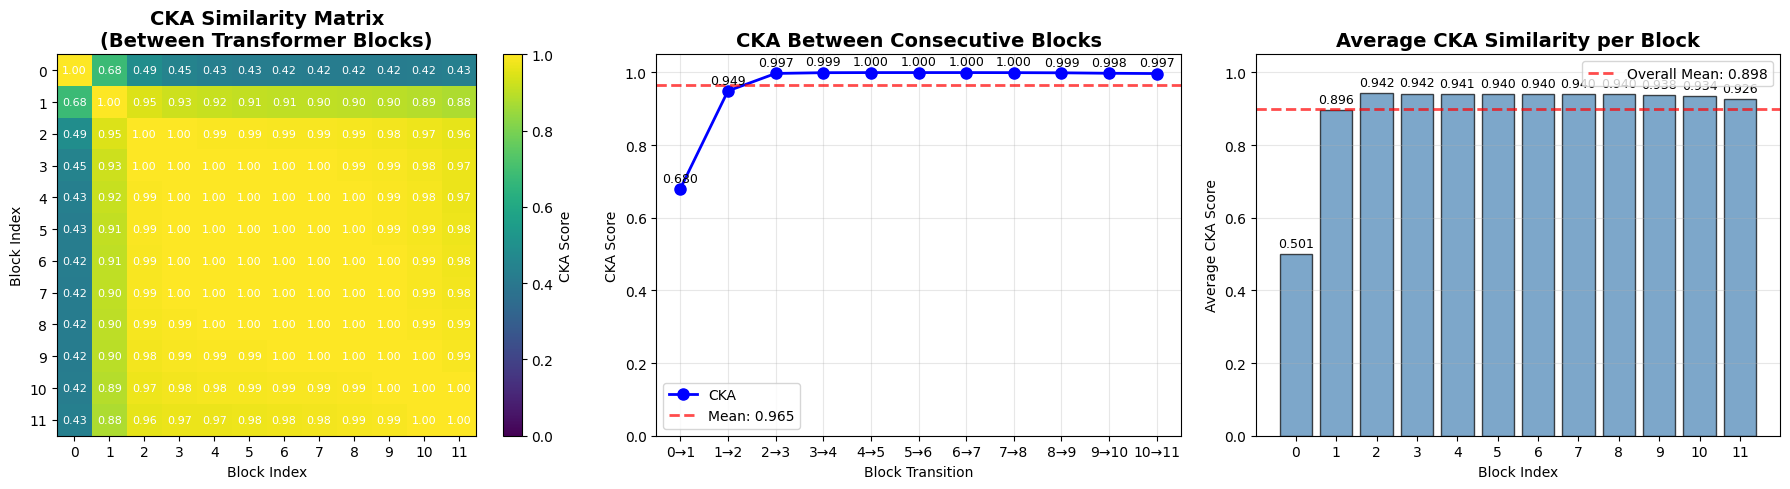


Analysis complete!

Interpretation Guide:
• High CKA (>0.8) between consecutive blocks:
  → Blocks learning very similar representations (potential redundancy)

• Medium CKA (0.5-0.8) between consecutive blocks:
  → Blocks refining representations while maintaining structure

• Low CKA (<0.5) between consecutive blocks:
  → Blocks learning distinct features (good differentiation)

• Decreasing CKA trend (early→late layers):
  → Hierarchical learning (basic → abstract features)

• Increasing CKA trend:
  → Representations converging to similar patterns


In [3]:
import torch
import torch.nn as nn
import os
import math
from contextlib import nullcontext
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from itertools import chain
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# Configuration
# ============================================================================
block_size = 128
batch_size = 8
eval_iters = 200

# ============================================================================
# CKA Implementation
# ============================================================================

class BatchwiseCKAComputer:
    """Compute CKA using streaming/batchwise updates."""
    def __init__(self, num_layers):
        self.num_layers = num_layers
        # Running sums for cross-covariance and self-covariance
        self.cross_cov = {}
        self.self_cov = {}
        self.n_samples = 0
        
    def update_batch(self, hidden_states):
        """
        hidden_states: list of tensors [batch_size, seq_len, hidden_dim]
        Flatten to [batch_size * seq_len, hidden_dim] for CKA computation
        """
        batch_size = hidden_states[0].shape[0]
        seq_len = hidden_states[0].shape[1]
        n = batch_size * seq_len
        
        # Flatten each layer's hidden states
        flattened = []
        for h in hidden_states:
            flattened.append(h.reshape(-1, h.shape[-1]))  # [n, d]
        
        # Update cross-covariance and self-covariance matrices
        for i in range(self.num_layers):
            for j in range(i, self.num_layers):
                key = (i, j)
                X = flattened[i]  # [n, d_i]
                Y = flattened[j]  # [n, d_j]
                
                # Compute gram matrices: K = X @ X.T, L = Y @ Y.T
                K = X @ X.T  # [n, n]
                L = Y @ Y.T  # [n, n]
                
                # HSIC = trace(K @ L)
                cross_hsic = torch.trace(K @ L).item()
                
                if key not in self.cross_cov:
                    self.cross_cov[key] = 0.0
                self.cross_cov[key] += cross_hsic
                
                # Self-covariance (for normalization)
                if i == j:
                    self_hsic = torch.trace(K @ K).item()
                    if i not in self.self_cov:
                        self.self_cov[i] = 0.0
                    self.self_cov[i] += self_hsic
        
        self.n_samples += n
    
    def compute_cka(self, i, j):
        """Compute CKA between layer i and j."""
        key = (min(i, j), max(i, j))
        if key not in self.cross_cov:
            return 0.0
        
        numerator = self.cross_cov[key]
        denominator = math.sqrt(self.self_cov[i] * self.self_cov[j])
        
        if denominator == 0:
            return 0.0
        
        return numerator / denominator
    
    def get_cka_matrix(self):
        """Return full CKA similarity matrix."""
        matrix = torch.zeros(self.num_layers, self.num_layers)
        for i in range(self.num_layers):
            for j in range(self.num_layers):
                matrix[i, j] = self.compute_cka(i, j)
        return matrix


# ============================================================================
# Data Loading
# ============================================================================

# Poor man's data loader
dataset = '/kaggle/input/wikitext/wikitext103'
data_dir = os.path.join('data', dataset)

def get_batch(split, device, device_type):
    """Load a batch of data from memmap files."""
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    
    if device_type == 'cuda':
        # Pin arrays x,y, which allows us to move them to GPU asynchronously
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    
    return x, y


# ============================================================================
# Model Loading and CKA Computation
# ============================================================================

# Model loading parameters
init_from = 'resume'
out_dir = './'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'

# Set device and dtype
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
device_type = 'cuda' if 'cuda' in device else 'cpu'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# # Load model
print(f"Loading model from {out_dir}...")
ckpt_path = '/kaggle/input/cka-models/pytorch/default/1/ckpt_best_sqrt_L_scaling.pt' #'/kaggle/working/ckpt_best_sqrt_L_scaling.pt' #'/kaggle/input/gpt-rezero/pytorch/default/1/ckpt_best.pt'
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])

model = GPT(gptconf)


# # model init
# model_args = dict(n_layer=12, n_head=12, n_embd=768, block_size=128,
#                   bias=False, vocab_size=50304, dropout=0.1) # start with model_args from command line
# gptconf = GPTConfig(**model_args)
# model = GPT(gptconf)


state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'
for k, v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Get model architecture info
num_blocks = model.config.n_layer  # Number of transformer blocks
hidden_size = model.config.n_embd
print(f"Model loaded: {num_blocks} transformer blocks, {hidden_size} hidden size")
print(f"Block size: {block_size}, Batch size: {batch_size}")
print(f"Will compute CKA for {num_blocks-1} consecutive block pairs")

# Initialize CKA computer for transformer blocks
cka_computer = BatchwiseCKAComputer(num_blocks)

# Process batches
print(f"\n{'='*70}")
print("Processing batches and computing CKA statistics...")
print(f"Collecting representations from {num_blocks} transformer blocks...")
print(f"Processing {eval_iters} iterations...")
print(f"{'='*70}\n")

total_loss = 0
total_tokens = 0

for k in tqdm(range(eval_iters), desc="Computing CKA"):
    X, Y = get_batch('train', device, device_type)
    
    with torch.no_grad():
        # Forward pass - collect hidden states after each block
        block_outputs = []
        x = X
        labels = Y
        
        # Get embedding (but don't include in CKA computation)
        tok_emb = model.transformer.wte(x)
        pos = torch.arange(0, x.size(1), dtype=torch.long, device=device)
        pos_emb = model.transformer.wpe(pos)
        x = model.transformer.drop(tok_emb + pos_emb)
        
        # Pass through transformer blocks and collect output after each block
        for block_idx, block in enumerate(model.transformer.h):
            x = block(x)
            # Store the output of this block on CPU to save GPU memory
            block_outputs.append(x.cpu())
        
        # Compute loss (no final LayerNorm in your model)
        logits = model.lm_head(x)
        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            labels.view(-1)
        )
        
        total_loss += loss.item() * x.numel()
        total_tokens += x.numel()
        
        # Update CKA statistics with block outputs
        cka_computer.update_batch(block_outputs)

# ============================================================================
# Results and Visualization
# ============================================================================

# Compute final results
print(f"\n{'='*70}")
print(f"Processed {eval_iters} batches with {cka_computer.n_samples} total samples")
print(f"Total tokens processed: {total_tokens}")

# Compute perplexity
average_loss = total_loss / total_tokens
perplexity = math.exp(average_loss)
print(f"Average loss: {average_loss:.4f}")
print(f"Perplexity on WikiText-103: {perplexity:.4f}")

# Get CKA results between consecutive blocks
print(f"\n{'='*70}")
print(f"CKA Scores (consecutive transformer blocks):")
print(f"{'='*70}")
cka_scores = []
for i in range(num_blocks - 1):
    cka_score = cka_computer.compute_cka(i, i + 1)
    cka_scores.append(cka_score)
    print(f"Block {i} → Block {i+1}: {cka_score:.4f}")

# Get full CKA matrix
cka_matrix = cka_computer.get_cka_matrix()

# Print some additional statistics
print(f"\n{'='*70}")
print("Additional CKA Statistics:")
print(f"{'='*70}")
print(f"Average consecutive block CKA: {np.mean(cka_scores):.4f}")
print(f"Min consecutive block CKA: {np.min(cka_scores):.4f}")
print(f"Max consecutive block CKA: {np.max(cka_scores):.4f}")
print(f"Std consecutive block CKA: {np.std(cka_scores):.4f}")

# Check similarity between first and last block
first_last_cka = cka_computer.compute_cka(0, num_blocks - 1)
print(f"\nFirst-to-Last block CKA (Block 0 → Block {num_blocks-1}): {first_last_cka:.4f}")

# Additional interesting comparisons
print(f"\n{'='*70}")
print("Additional Block Comparisons:")
print(f"{'='*70}")
if num_blocks >= 3:
    print(f"Block 0 → Block 2: {cka_computer.compute_cka(0, 2):.4f}")
if num_blocks >= 4:
    print(f"Block 0 → Block 3: {cka_computer.compute_cka(0, 3):.4f}")
if num_blocks >= 6:
    print(f"Block 1 → Block 5: {cka_computer.compute_cka(1, 5):.4f}")
    print(f"Block 2 → Block 5: {cka_computer.compute_cka(2, 5):.4f}")

# Plotting
print(f"\n{'='*70}")
print("Generating visualizations...")
print(f"{'='*70}\n")

fig = plt.figure(figsize=(18, 5))

# Plot 1: CKA Matrix
ax1 = plt.subplot(1, 3, 1)
im1 = ax1.imshow(cka_matrix.numpy(), cmap='viridis', aspect='auto', vmin=0, vmax=1)
cbar1 = plt.colorbar(im1, ax=ax1, label='CKA Score')
ax1.set_title("CKA Similarity Matrix\n(Between Transformer Blocks)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Block Index")
ax1.set_ylabel("Block Index")
ax1.set_xticks(range(num_blocks))
ax1.set_yticks(range(num_blocks))

# Add text annotations to the heatmap
for i in range(num_blocks):
    for j in range(num_blocks):
        text = ax1.text(j, i, f'{cka_matrix[i, j].item():.2f}',
                       ha="center", va="center", color="white", fontsize=8)

# Plot 2: Consecutive block comparisons
ax2 = plt.subplot(1, 3, 2)
block_pairs = [f"{i}→{i+1}" for i in range(len(cka_scores))]
x_pos = range(len(cka_scores))

ax2.plot(x_pos, cka_scores, 'b-o', label='CKA', linewidth=2, markersize=8)
ax2.axhline(y=np.mean(cka_scores), color='r', linestyle='--', 
            label=f'Mean: {np.mean(cka_scores):.3f}', alpha=0.7, linewidth=2)
ax2.set_title("CKA Between Consecutive Blocks", fontsize=14, fontweight='bold')
ax2.set_xlabel("Block Transition")
ax2.set_ylabel("CKA Score")
ax2.legend(fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(block_pairs, rotation=0, ha='center')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

# Add value labels on the points
for i, score in enumerate(cka_scores):
    ax2.text(i, score + 0.02, f'{score:.3f}', ha='center', fontsize=9)

# Plot 3: Layer-wise average similarity
ax3 = plt.subplot(1, 3, 3)
avg_similarity = cka_matrix.mean(dim=1).numpy()
bars = ax3.bar(range(num_blocks), avg_similarity, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axhline(y=np.mean(avg_similarity), color='r', linestyle='--', 
            label=f'Overall Mean: {np.mean(avg_similarity):.3f}', alpha=0.7, linewidth=2)
ax3.set_title("Average CKA Similarity per Block", fontsize=14, fontweight='bold')
ax3.set_xlabel("Block Index")
ax3.set_ylabel("Average CKA Score")
ax3.set_xticks(range(num_blocks))
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1.05])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, avg_similarity)):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
             f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('block_cka_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'block_cka_analysis.png'")
plt.show()

print(f"\n{'='*70}")
print("Analysis complete!")
print(f"{'='*70}")
print("\nInterpretation Guide:")
print("=" * 70)
print("• High CKA (>0.8) between consecutive blocks:")
print("  → Blocks learning very similar representations (potential redundancy)")
print("\n• Medium CKA (0.5-0.8) between consecutive blocks:")
print("  → Blocks refining representations while maintaining structure")
print("\n• Low CKA (<0.5) between consecutive blocks:")
print("  → Blocks learning distinct features (good differentiation)")
print("\n• Decreasing CKA trend (early→late layers):")
print("  → Hierarchical learning (basic → abstract features)")
print("\n• Increasing CKA trend:")
print("  → Representations converging to similar patterns")
print("=" * 70)

In [4]:
import torch
import torch.nn as nn
import copy
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================================
# Layer Removal Functions
# ============================================================================

def identify_redundant_layers(cka_scores, threshold=0.95):
    """
    Identify layers to remove based on CKA threshold.
    Returns indices of layers that should be removed (the second layer in high-CKA pairs).
    
    Args:
        cka_scores: list of CKA scores between consecutive blocks
        threshold: CKA threshold above which layers are considered redundant
    
    Returns:
        list of layer indices to remove
    """
    layers_to_remove = []
    for i, score in enumerate(cka_scores):
        if score >= threshold:
            # Remove the second layer in the pair (i+1)
            layers_to_remove.append(i + 1)
    
    return sorted(list(set(layers_to_remove)))


def remove_layers_from_model(model, layers_to_remove):
    """
    Create a new model with specified layers removed.
    
    Args:
        model: original GPT model
        layers_to_remove: list of block indices to remove
    
    Returns:
        new model with layers removed
    """
    # Create a deep copy of the model
    new_model = copy.deepcopy(model)
    
    # Get the original blocks
    original_blocks = list(new_model.transformer.h)
    
    # Create new block list without the removed layers
    new_blocks = [block for i, block in enumerate(original_blocks) 
                  if i not in layers_to_remove]
    
    # Replace the module list
    new_model.transformer.h = nn.ModuleList(new_blocks)
    
    # Update config
    new_model.config.n_layer = len(new_blocks)
    
    return new_model


def evaluate_perplexity(model, device, device_type, ctx, eval_iters=200):
    """
    Evaluate perplexity on validation set.
    
    Args:
        model: model to evaluate
        device: device to run on
        device_type: 'cuda' or 'cpu'
        ctx: autocast context
        eval_iters: number of evaluation iterations
    
    Returns:
        perplexity, average_loss
    """
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for k in tqdm(range(eval_iters), desc="Evaluating", leave=False):
            X, Y = get_batch('val', device, device_type)
            
            with ctx:
                # Forward pass
                tok_emb = model.transformer.wte(X)
                pos = torch.arange(0, X.size(1), dtype=torch.long, device=device)
                pos_emb = model.transformer.wpe(pos)
                x = model.transformer.drop(tok_emb + pos_emb)
                
                # Pass through remaining blocks
                for block in model.transformer.h:
                    x = block(x)
                
                # Compute loss
                logits = model.lm_head(x)
                loss = nn.functional.cross_entropy(
                    logits.view(-1, logits.size(-1)), 
                    Y.view(-1)
                )
                
                total_loss += loss.item() * X.numel()
                total_tokens += X.numel()
    
    average_loss = total_loss / total_tokens
    perplexity = np.exp(average_loss)
    
    return perplexity, average_loss


# ============================================================================
# Main Analysis: Remove Layers and Measure Degradation
# ============================================================================

print(f"\n{'='*80}")
print("LAYER REMOVAL ANALYSIS")
print(f"{'='*80}\n")

# Define different CKA thresholds to test
thresholds = [ 0.99]

# Store results
results = []

# Baseline: Evaluate original model
print("Evaluating baseline model (no layers removed)...")
baseline_perplexity, baseline_loss = evaluate_perplexity(
    model, device, device_type, ctx, eval_iters=eval_iters
)
print(f"✓ Baseline Perplexity: {baseline_perplexity:.4f}")
print(f"✓ Baseline Loss: {baseline_loss:.4f}")

results.append({
    'threshold': 'baseline',
    'layers_removed': [],
    'num_removed': 0,
    'remaining_layers': num_blocks,
    'perplexity': baseline_perplexity,
    'loss': baseline_loss,
    'perplexity_increase': 0.0,
    'relative_increase': 0.0
})

print(f"\n{'-'*80}\n")

# Test different thresholds
for threshold in thresholds:
    print(f"Testing CKA threshold: {threshold}")
    print(f"{'-'*80}")
    
    # Identify layers to remove
    layers_to_remove = identify_redundant_layers(cka_scores, threshold=threshold)
    #layers_to_remove = [3,4,5,6,7,8,9,10]
    if len(layers_to_remove) == 0:
        print(f"  No layers exceed CKA threshold of {threshold}")
        print()
        continue
    
    print(f"  Layers to remove: {layers_to_remove[:-1]}")
    print(f"  Number of layers to remove: {len(layers_to_remove)-1}/{num_blocks}")
    
    # Create model with layers removed
    print(f"  Creating model with {len(layers_to_remove)-1} layers removed...")
    pruned_model = remove_layers_from_model(model, layers_to_remove[:-1])
    pruned_model = pruned_model.to(device)
    
    # Evaluate pruned model
    print(f"  Evaluating pruned model...")
    pruned_perplexity, pruned_loss = evaluate_perplexity(
        pruned_model, device, device_type, ctx, eval_iters=eval_iters
    )
    
    # Calculate degradation
    perplexity_increase = pruned_perplexity - baseline_perplexity
    relative_increase = (perplexity_increase / baseline_perplexity) * 100
    
    print(f"  ✓ Pruned Perplexity: {pruned_perplexity:.4f}")
    print(f"  ✓ Pruned Loss: {pruned_loss:.4f}")
    print(f"  ✓ Perplexity Increase: {perplexity_increase:.4f} ({relative_increase:.2f}%)")
    print()
    
    # Store results
    results.append({
        'threshold': threshold,
        'layers_removed': layers_to_remove,
        'num_removed': len(layers_to_remove),
        'remaining_layers': num_blocks - len(layers_to_remove),
        'perplexity': pruned_perplexity,
        'loss': pruned_loss,
        'perplexity_increase': perplexity_increase,
        'relative_increase': relative_increase
    })
    
    # Free memory
    del pruned_model
    torch.cuda.empty_cache()

# ============================================================================
# Results Summary
# ============================================================================

print(f"\n{'='*80}")
print("RESULTS SUMMARY")
print(f"{'='*80}\n")

# Create summary table
print(f"{'Threshold':<12} {'Removed':<10} {'Remaining':<12} {'Perplexity':<14} {'Increase':<14} {'Relative %':<12}")
print(f"{'-'*80}")

for result in results:
    threshold_str = 'Baseline' if result['threshold'] == 'baseline' else f"{result['threshold']:.2f}"
    print(f"{threshold_str:<12} {result['num_removed']:<10} {result['remaining_layers']:<12} "
          f"{result['perplexity']:<14.4f} {result['perplexity_increase']:<14.4f} {result['relative_increase']:<12.2f}")

print(f"{'-'*80}\n")




LAYER REMOVAL ANALYSIS

Evaluating baseline model (no layers removed)...


✓ Baseline Perplexity: 57.3798
✓ Baseline Loss: 4.0497

--------------------------------------------------------------------------------

Testing CKA threshold: 0.99
--------------------------------------------------------------------------------
  Layers to remove: [3, 4, 5, 6, 7, 8, 9, 10]
  Number of layers to remove: 8/12
  Creating model with 8 layers removed...
  Evaluating pruned model...


  ✓ Pruned Perplexity: 312.8904
  ✓ Pruned Loss: 5.7459
  ✓ Perplexity Increase: 255.5106 (445.30%)


RESULTS SUMMARY

Threshold    Removed    Remaining    Perplexity     Increase       Relative %  
--------------------------------------------------------------------------------
Baseline     0          12           57.3798        0.0000         0.00        
0.99         9          3            312.8904       255.5106       445.30      
--------------------------------------------------------------------------------



In [5]:
# (Full file — minimal edits for FixUp init + block-wise LR)
import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a single linear
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        # self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        self.flash = False
        if not self.flash:
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True
            )
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v  # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = y.transpose(1, 2).contiguous().view(B, T, C)  # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):
    """
    Transformer block WITH Pre-LayerNorm.
    Each residual branch is scaled by a fixed factor alpha = 1/sqrt(n_layer).
    """

    def __init__(self, config):
        super().__init__()
        self.attn = CausalSelfAttention(config)
        self.mlp = MLP(config)

        # --- Added: Pre-LayerNorm for attention and MLP ---
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.ln_2 = nn.LayerNorm(config.n_embd)

        # fixed scaling factor (not learnable)
        self.scale = 1.0 / 1.0 # math.sqrt(config.n_layer)

    def forward(self, x):
        # Pre-LN attention
        x = x + self.scale  * self.attn(self.ln_1(x))

        # Pre-LN MLP
        x = x + self.scale * self.mlp(self.ln_2(x))

        return x


@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304  # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 6
    n_head: int = 8
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True  # True: bias in Linears, False: faster slightly


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        # transformer modules
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            # NOTE: removed ln_f (final LayerNorm) entirely (kept that choice minimal)
        ))
        # language model head
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight tying: share token embedding and lm_head weights
        # this keeps behavior similar to original GPT implementations
        self.transformer.wte.weight = self.lm_head.weight

        # init all weights (base)
        self.apply(self._init_weights)

        # -------------------------
        # Minimal FixUp-style edits
        # 1) initialize final projection weights of residual branches with std = L**(-0.75)
        # 2) zero-init biases of final projections if present
        # This prevents the model from cancelling the fixed residual scale alpha via large initial residuals.
        # -------------------------
        L = max(1, config.n_layer)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                # FixUp-style scaled init for final projection of each branch
                torch.nn.init.normal_(p, mean=0.0, std=(L ** (-0.75)))
            if pn.endswith('c_proj.bias'):
                # zero biases for stability (if bias exists)
                with torch.no_grad():
                    p.zero_()

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params() / 1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return number of parameters. If non_embedding=True subtract position embeddings
        to match many published counts.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx: (b, t) long tensor of token indices
        targets: (b, t) long tensor for computing cross-entropy loss (optional)
        """
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device)  # shape (t)

        # token + position embeddings
        tok_emb = self.transformer.wte(idx)  # (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos)  # (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)

        # forward through transformer blocks (pre-LN)
        for block in self.transformer.h:
            x = block(x)

        # no final LayerNorm (ln_f) is applied (kept minimal per request)

        if targets is not None:
            # full logits for loss computation
            logits = self.lm_head(x)  # (b, t, vocab)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # during inference, only compute logits for last token to save compute
            logits = self.lm_head(x[:, [-1], :])  # (b, 1, vocab)
            loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        """
        Reduce block size (positional embeddings and attention mask) for memory savings.
        """
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:, :, :block_size, :block_size]

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        """
        Minimal change: use a smaller learning rate for transformer block parameters so that
        the optimizer does not trivially amplify residual branch weights and cancel the effect of alpha.
        Block params (inside transformer.h) get lr = base_lr / sqrt(L). Other params use base_lr.
        """
        L = max(1, self.config.n_layer)
        lr_block = learning_rate / math.sqrt(L)
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}

        # split parameters into block params (transformer.h.*) and others
        block_decay = []
        block_nodecay = []
        other_decay = []
        other_nodecay = []

        for n, p in param_dict.items():
            is_block = n.split('.')[0] == 'transformer' and ('.h.' in n)
            # treat bias and 1-d tensors as no-decay per common practice
            if is_block:
                if p.dim() >= 2:
                    block_decay.append(p)
                else:
                    block_nodecay.append(p)
            else:
                if p.dim() >= 2:
                    other_decay.append(p)
                else:
                    other_nodecay.append(p)

        optim_groups = [
            {'params': block_decay, 'weight_decay': weight_decay, 'lr': lr_block},
            {'params': block_nodecay, 'weight_decay': 0.0, 'lr': lr_block},
            {'params': other_decay, 'weight_decay': weight_decay, 'lr': learning_rate},
            {'params': other_nodecay, 'weight_decay': 0.0, 'lr': learning_rate},
        ]

        # choose fused AdamW when available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, eps=1e-4, **extra_args)
        print(f"using fused AdamW: {use_fused}")
        print(f"block lr: {lr_block:.3e}, other lr: {learning_rate:.3e}")
        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd // cfg.n_head, cfg.block_size
        flops_per_token = 6 * N + 12 * L * H * Q * T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        flops_achieved = flops_per_iter * (1.0 / dt)
        flops_promised = 312e12  # A100 bfloat16 peak flops ~312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        autoregressive generation: append tokens to idx max_new_tokens times
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
"""
This training script can be run both on a single gpu in debug mode,
and also in a larger training run with distributed data parallel (ddp).

To run on a single GPU, example:
$ python train.py --batch_size=32 --compile=False

To run with DDP on 4 gpus on 1 node, example:
$ torchrun --standalone --nproc_per_node=4 train.py

To run with DDP on 4 gpus across 2 nodes, example:
- Run on the first (master) node with example IP 123.456.123.456:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=0 --master_addr=123.456.123.456 --master_port=1234 train.py
- Run on the worker node:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=1 --master_addr=123.456.123.456 --master_port=1234 train.py
(If your cluster does not have Infiniband interconnect prepend NCCL_IB_DISABLE=1)
"""


import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

#from model import GPTConfig, GPT

# -----------------------------------------------------------------------------
# default config values designed to train a gpt2 (124M) on OpenWebText
# I/O
out_dir = './'
eval_interval = 200
log_interval = 1
eval_iters = 200
eval_only = False # if True, script exits right after the first eval
always_save_checkpoint = True # if True, always save a checkpoint after each eval
init_from = 'scratch' # 'scratch' or 'resume' or 'gpt2*'
# wandb logging
wandb_log = False # disabled by default
wandb_project = 'ts'
wandb_run_name = 'gpt2' # 'run' + str(time.time())
# data
dataset = '/kaggle/input/wikitext/wikitext103' 
gradient_accumulation_steps = 2 # used to simulate larger batch sizes
batch_size = 16 # if gradient_accumulation_steps > 1, this is the micro-batch size  #1801350/160=11258 batches
block_size = 256
# model
n_layer = 12
n_head = 12
n_embd =  768
dropout = 0.1 # for pretraining 0 is good, for finetuning try 0.1+
bias = False # do we use bias inside LayerNorm and Linear layers?
# adamw optimizer
learning_rate = 5e-4 # max learning rate
max_iters = 10000 # total number of training iterations
weight_decay = 0.01
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
# learning rate decay settings
decay_lr = True # whether to decay the learning rate
warmup_iters = 2000 # how many steps to warm up for
lr_decay_iters = 20000 # should be ~= max_iters per Chinchilla
min_lr = 5e-6 # minimum learning rate, should be ~= learning_rate/10 per Chinchilla
# DDP settings
backend = 'nccl' # 'nccl', 'gloo', etc.
# system
device = 'cuda' # examples: 'cpu', 'cuda', 'cuda:0', 'cuda:1' etc., or try 'mps' on macbooks
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
compile = False # use PyTorch 2.0 to compile the model to be faster
# # -----------------------------------------------------------------------------
# config_keys = [k for k,v in globals().items() if not k.startswith('_') and isinstance(v, (int, float, bool, str))]
# exec(open('configurator.py').read()) # overrides from command line or config file
# config = {k: globals()[k] for k in config_keys} # will be useful for logging
# -----------------------------------------------------------------------------

# various inits, derived attributes, I/O setup
ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
if ddp:
    init_process_group(backend=backend)
    ddp_rank = int(os.environ['RANK'])
    ddp_local_rank = int(os.environ['LOCAL_RANK'])
    ddp_world_size = int(os.environ['WORLD_SIZE'])
    device = f'cuda:{ddp_local_rank}'
    torch.cuda.set_device(device)
    master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
    seed_offset = ddp_rank # each process gets a different seed
    # world_size number of processes will be training simultaneously, so we can scale
    # down the desired gradient accumulation iterations per process proportionally
    assert gradient_accumulation_steps % ddp_world_size == 0
    gradient_accumulation_steps //= ddp_world_size
else:
    # if not ddp, we are running on a single gpu, and one process
    master_process = True
    seed_offset = 0
    ddp_world_size = 1
tokens_per_iter = gradient_accumulation_steps * ddp_world_size * batch_size * block_size
print(f"tokens per iteration will be: {tokens_per_iter:,}")

if master_process:
    os.makedirs(out_dir, exist_ok=True)
torch.manual_seed(1337 + seed_offset)
torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# poor man's data loader
data_dir = os.path.join('data', dataset)
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

# init these up here, can override if init_from='resume' (i.e. from a checkpoint)
iter_num = 0
best_val_loss = 1e9

# attempt to derive vocab_size from the dataset
meta_path = os.path.join(data_dir, 'meta.pkl')
meta_vocab_size = None
if os.path.exists(meta_path):
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    meta_vocab_size = meta['vocab_size']
    print(f"found vocab_size = {meta_vocab_size} (inside {meta_path})")

# model init
model_args = dict(n_layer=n_layer, n_head=n_head, n_embd=n_embd, block_size=block_size,
                  bias=bias, vocab_size=None, dropout=dropout) # start with model_args from command line
if init_from == 'scratch':
    # init a new model from scratch
    print("Initializing a new model from scratch")
    # determine the vocab size we'll use for from-scratch training
    if meta_vocab_size is None:
        print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
    model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
elif init_from == 'resume':
    print(f"Resuming training from {out_dir}")
    # resume training from a checkpoint.
    ckpt_path = os.path.join(out_dir, 'ckpt.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    checkpoint_model_args = checkpoint['model_args']
    # force these config attributes to be equal otherwise we can't even resume training
    # the rest of the attributes (e.g. dropout) can stay as desired from command line
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = checkpoint_model_args[k]
    # create the model
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
    state_dict = checkpoint['model']
    # fix the keys of the state dictionary :(
    # honestly no idea how checkpoints sometimes get this prefix, have to debug more
    unwanted_prefix = '_orig_mod.'
    for k,v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    model.load_state_dict(state_dict)
    iter_num = checkpoint['iter_num']
    best_val_loss = checkpoint['best_val_loss']
elif init_from.startswith('gpt2'):
    print(f"Initializing from OpenAI GPT-2 weights: {init_from}")
    # initialize from OpenAI GPT-2 weights
    override_args = dict(dropout=dropout)
    model = GPT.from_pretrained(init_from, override_args)
    # read off the created config params, so we can store them into checkpoint correctly
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = getattr(model.config, k)
# crop down the model block size if desired, using model surgery
if block_size < model.config.block_size:
    model.crop_block_size(block_size)
    model_args['block_size'] = block_size # so that the checkpoint will have the right value
model.to(device)

# initialize a GradScaler. If enabled=False scaler is a no-op
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

# optimizer
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
if init_from == 'resume':
    optimizer.load_state_dict(checkpoint['optimizer'])
checkpoint = None # free up memory

# compile the model
if compile:
    print("compiling the model... (takes a ~minute)")
    unoptimized_model = model
    model = torch.compile(model) # requires PyTorch 2.0

# wrap model into DDP container
if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])

# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with ctx:
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()  # convert to Python float
    # Check for NaNs after both splits have been computed
    if math.isnan(out['train']) or math.isnan(out['val']):
        print("NaN detected in train or val loss:", out)
    print(out)
    model.train()
    return out


# learning rate decay scheduler (cosine with warmup)
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2) if it > lr_decay_iters, return min learning rate
    if it > lr_decay_iters:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
    return min_lr + coeff * (learning_rate - min_lr)

# logging
if wandb_log and master_process:
    import wandb
    wandb.init(project=wandb_project, name=wandb_run_name, config=config)

# training loop
X, Y = get_batch('train') # fetch the very first batch
t0 = time.time()
local_iter_num = 0 # number of iterations in the lifetime of this process
raw_model = model.module if ddp else model # unwrap DDP container if needed
running_mfu = -1.0


save_interval = 20000  # Save every 20,000 iterations
while True:
    # determine and set the learning rate for this iteration
    lr = get_lr(iter_num) if decay_lr else learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # ---- Evaluate periodically ----
    if iter_num % eval_interval == 0 and master_process:
        losses = estimate_loss()
        print(f"Step {iter_num}: train {losses['train']:.4f}, val {losses['val']:.4f}")

        # # (1) Save checkpoint every N iterations
        # if iter_num % save_interval == 0:
        #     ckpt_path = os.path.join(out_dir, f"ckpt_it{iter_num}.pt")
        #     ckpt = {
        #         'model': raw_model.state_dict(),
        #         'optimizer': optimizer.state_dict(),
        #         'model_args': model_args,
        #         'iter_num': iter_num,
        #         'best_val_loss': best_val_loss,
        #     }
        #     torch.save(ckpt, ckpt_path)
        #     print(f"💾 Periodic checkpoint saved to {ckpt_path}")

        # (2) Save best-loss checkpoint
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            ckpt_path = os.path.join(out_dir, "ckpt_best_no_scaling.pt")
            ckpt = {
                'model': raw_model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'model_args': model_args,
                'iter_num': iter_num,
                'best_val_loss': best_val_loss,
            }
            torch.save(ckpt, ckpt_path)
            print(f"🏆 New best model saved to {ckpt_path} (val loss: {best_val_loss:.4f})")

        

    # ---- Exit early for eval-only ----
    if iter_num == 0 and eval_only:
        break
    

    # forward backward update, with optional gradient accumulation to simulate larger batch size
    # and using the GradScaler if data type is float16
    for micro_step in range(gradient_accumulation_steps):
        if ddp:
            # in DDP training we only need to sync gradients at the last micro step.
            # the official way to do this is with model.no_sync() context manager, but
            # I really dislike that this bloats the code and forces us to repeat code
            # looking at the source of that context manager, it just toggles this variable
            model.require_backward_grad_sync = (micro_step == gradient_accumulation_steps - 1)
        with ctx:
            logits, loss = model(X, Y)
            loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
        # immediately async prefetch next batch while model is doing the forward pass on the GPU
        X, Y = get_batch('train')
        # backward pass, with gradient scaling if training in fp16
        scaler.scale(loss).backward()
    # clip the gradient
    if grad_clip != 0.0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    # step the optimizer and scaler if training in fp16
    scaler.step(optimizer)
    scaler.update()
    # flush the gradients as soon as we can, no need for this memory anymore
    optimizer.zero_grad(set_to_none=True)

    # # timing and logging
    # t1 = time.time()
    # dt = t1 - t0
    # t0 = t1
    # if iter_num % log_interval == 0 and master_process:
    #     # get loss as float. note: this is a CPU-GPU sync point
    #     # scale up to undo the division above, approximating the true total loss (exact would have been a sum)
    #     lossf = loss.item() * gradient_accumulation_steps
    #     if local_iter_num >= 5: # let the training loop settle a bit
    #         mfu = raw_model.estimate_mfu(batch_size * gradient_accumulation_steps, dt)
    #         running_mfu = mfu if running_mfu == -1.0 else 0.9*running_mfu + 0.1*mfu
    #     print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")
    iter_num += 1
    local_iter_num += 1

    # termination conditions
    if iter_num > max_iters:
        break

if ddp:
    destroy_process_group()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Loading model from ./...
number of parameters: 123.60M
Model loaded: 12 transformer blocks, 768 hidden size
Block size: 128, Batch size: 8
Will compute CKA for 11 consecutive block pairs

Processing batches and computing CKA statistics...
Processing 200 iterations...



Computing CKA: 100%|██████████| 200/200 [05:58<00:00,  1.79s/it]



Processed 200 batches with 204800 total samples
Total tokens processed: 157286400
Average loss: 4.2469
Perplexity on WikiText-103: 69.8862

CKA Scores (consecutive transformer blocks):
Block 0 → Block 1: 0.9592
Block 1 → Block 2: 0.9970
Block 2 → Block 3: 0.9990
Block 3 → Block 4: 0.9991
Block 4 → Block 5: 0.9994
Block 5 → Block 6: 0.9995
Block 6 → Block 7: 0.9993
Block 7 → Block 8: 0.9985
Block 8 → Block 9: 0.9947
Block 9 → Block 10: 0.9657
Block 10 → Block 11: 0.9221

Additional CKA Statistics:
Average consecutive block CKA: 0.9849
Min consecutive block CKA: 0.9221
Max consecutive block CKA: 0.9995
Std consecutive block CKA: 0.0242

First-to-Last block CKA (Block 0 → Block 11): 0.5519

Additional Block Comparisons:
Block 0 → Block 2: 0.9545
Block 0 → Block 3: 0.9477
Block 1 → Block 5: 0.9824
Block 2 → Block 5: 0.9930

Generating visualizations...

Visualization saved as 'block_cka_analysis.png'


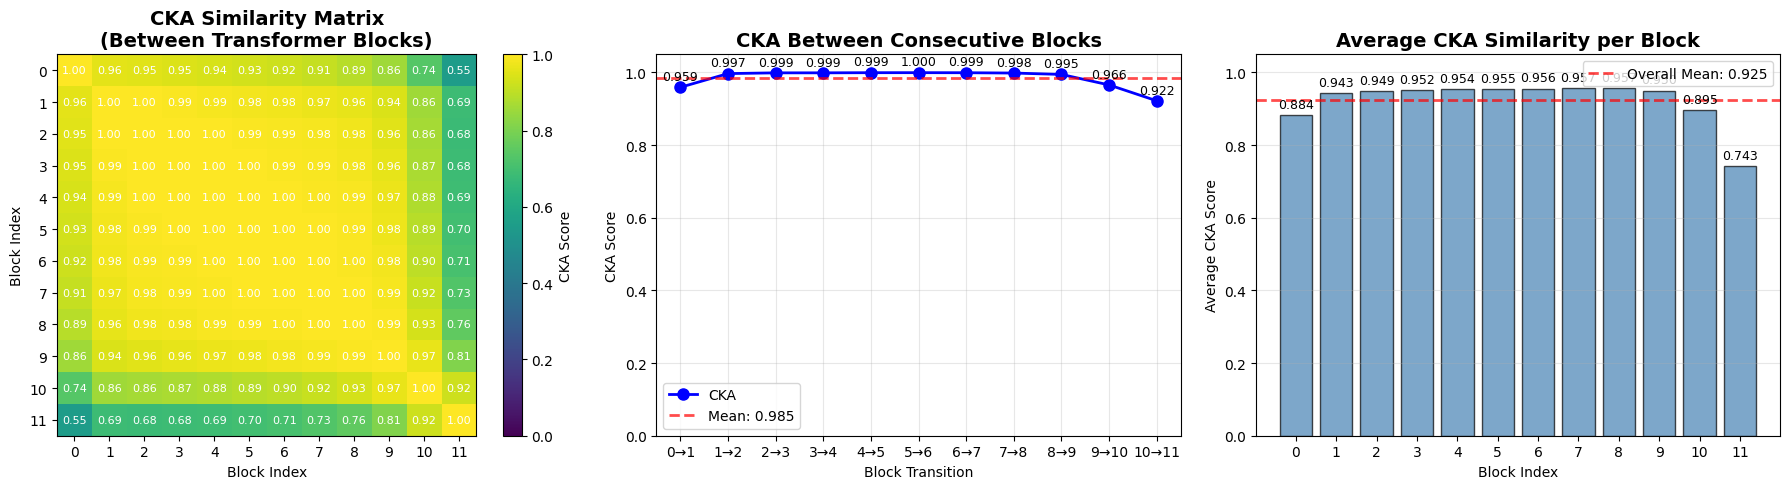


Analysis complete!

Interpretation Guide:
• High CKA (>0.8) between consecutive blocks:
  → Blocks learning very similar representations (potential redundancy)

• Medium CKA (0.5-0.8) between consecutive blocks:
  → Blocks refining representations while maintaining structure

• Low CKA (<0.5) between consecutive blocks:
  → Blocks learning distinct features (good differentiation)

• Decreasing CKA trend (early→late layers):
  → Hierarchical learning (basic → abstract features)

• Increasing CKA trend:
  → Representations converging to similar patterns


In [6]:
import torch
import torch.nn as nn
import os
import math
from contextlib import nullcontext
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from itertools import chain
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# Configuration
# ============================================================================
block_size = 128
batch_size = 8
eval_iters = 200

# ============================================================================
# CKA Implementation
# ============================================================================

class BatchwiseCKAComputer:
    """Compute CKA using streaming/batchwise updates."""
    def __init__(self, num_layers):
        self.num_layers = num_layers
        # Running sums for cross-covariance and self-covariance
        self.cross_cov = {}
        self.self_cov = {}
        self.n_samples = 0
        
    def update_batch(self, hidden_states):
        """
        hidden_states: list of tensors [batch_size, seq_len, hidden_dim]
        Flatten to [batch_size * seq_len, hidden_dim] for CKA computation
        """
        batch_size = hidden_states[0].shape[0]
        seq_len = hidden_states[0].shape[1]
        n = batch_size * seq_len
        
        # Flatten each layer's hidden states
        flattened = []
        for h in hidden_states:
            flattened.append(h.reshape(-1, h.shape[-1]))  # [n, d]
        
        # Update cross-covariance and self-covariance matrices
        for i in range(self.num_layers):
            for j in range(i, self.num_layers):
                key = (i, j)
                X = flattened[i]  # [n, d_i]
                Y = flattened[j]  # [n, d_j]
                
                # Compute gram matrices: K = X @ X.T, L = Y @ Y.T
                K = X @ X.T  # [n, n]
                L = Y @ Y.T  # [n, n]
                
                # HSIC = trace(K @ L)
                cross_hsic = torch.trace(K @ L).item()
                
                if key not in self.cross_cov:
                    self.cross_cov[key] = 0.0
                self.cross_cov[key] += cross_hsic
                
                # Self-covariance (for normalization)
                if i == j:
                    self_hsic = torch.trace(K @ K).item()
                    if i not in self.self_cov:
                        self.self_cov[i] = 0.0
                    self.self_cov[i] += self_hsic
        
        self.n_samples += n
    
    def compute_cka(self, i, j):
        """Compute CKA between layer i and j."""
        key = (min(i, j), max(i, j))
        if key not in self.cross_cov:
            return 0.0
        
        numerator = self.cross_cov[key]
        denominator = math.sqrt(self.self_cov[i] * self.self_cov[j])
        
        if denominator == 0:
            return 0.0
        
        return numerator / denominator
    
    def get_cka_matrix(self):
        """Return full CKA similarity matrix."""
        matrix = torch.zeros(self.num_layers, self.num_layers)
        for i in range(self.num_layers):
            for j in range(self.num_layers):
                matrix[i, j] = self.compute_cka(i, j)
        return matrix


# ============================================================================
# Data Loading
# ============================================================================

# Poor man's data loader
dataset = '/kaggle/input/wikitext/wikitext103'
data_dir = os.path.join('data', dataset)

def get_batch(split, device, device_type):
    """Load a batch of data from memmap files."""
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    
    if device_type == 'cuda':
        # Pin arrays x,y, which allows us to move them to GPU asynchronously
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    
    return x, y


# ============================================================================
# Model Loading and CKA Computation
# ============================================================================

# Model loading parameters
init_from = 'resume'
out_dir = './'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'

# Set device and dtype
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
device_type = 'cuda' if 'cuda' in device else 'cpu'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# # Load model
print(f"Loading model from {out_dir}...")
ckpt_path = '/kaggle/input/cka-models/pytorch/default/1/ckpt_best_no_scaling.pt' #'/kaggle/working/ckpt_best_no_scaling.pt' #'/kaggle/input/gpt-rezero/pytorch/default/1/ckpt_best.pt'
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])

model = GPT(gptconf)


# # model init
# model_args = dict(n_layer=12, n_head=12, n_embd=768, block_size=128,
#                   bias=False, vocab_size=50304, dropout=0.1) # start with model_args from command line
# gptconf = GPTConfig(**model_args)
# model = GPT(gptconf)


state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'
for k, v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Get model architecture info
num_blocks = model.config.n_layer  # Number of transformer blocks
hidden_size = model.config.n_embd
print(f"Model loaded: {num_blocks} transformer blocks, {hidden_size} hidden size")
print(f"Block size: {block_size}, Batch size: {batch_size}")
print(f"Will compute CKA for {num_blocks-1} consecutive block pairs")

# Initialize CKA computer for transformer blocks
cka_computer = BatchwiseCKAComputer(num_blocks)

# Process batches
print(f"\n{'='*70}")
print("Processing batches and computing CKA statistics...")
print(f"Collecting representations from {num_blocks} transformer blocks...")
print(f"Processing {eval_iters} iterations...")
print(f"{'='*70}\n")

total_loss = 0
total_tokens = 0

for k in tqdm(range(eval_iters), desc="Computing CKA"):
    X, Y = get_batch('train', device, device_type)
    
    with torch.no_grad():
        # Forward pass - collect hidden states after each block
        block_outputs = []
        x = X
        labels = Y
        
        # Get embedding (but don't include in CKA computation)
        tok_emb = model.transformer.wte(x)
        pos = torch.arange(0, x.size(1), dtype=torch.long, device=device)
        pos_emb = model.transformer.wpe(pos)
        x = model.transformer.drop(tok_emb + pos_emb)
        
        # Pass through transformer blocks and collect output after each block
        for block_idx, block in enumerate(model.transformer.h):
            x = block(x)
            # Store the output of this block on CPU to save GPU memory
            block_outputs.append(x.cpu())
        
        # Compute loss (no final LayerNorm in your model)
        logits = model.lm_head(x)
        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            labels.view(-1)
        )
        
        total_loss += loss.item() * x.numel()
        total_tokens += x.numel()
        
        # Update CKA statistics with block outputs
        cka_computer.update_batch(block_outputs)

# ============================================================================
# Results and Visualization
# ============================================================================

# Compute final results
print(f"\n{'='*70}")
print(f"Processed {eval_iters} batches with {cka_computer.n_samples} total samples")
print(f"Total tokens processed: {total_tokens}")

# Compute perplexity
average_loss = total_loss / total_tokens
perplexity = math.exp(average_loss)
print(f"Average loss: {average_loss:.4f}")
print(f"Perplexity on WikiText-103: {perplexity:.4f}")

# Get CKA results between consecutive blocks
print(f"\n{'='*70}")
print(f"CKA Scores (consecutive transformer blocks):")
print(f"{'='*70}")
cka_scores = []
for i in range(num_blocks - 1):
    cka_score = cka_computer.compute_cka(i, i + 1)
    cka_scores.append(cka_score)
    print(f"Block {i} → Block {i+1}: {cka_score:.4f}")

# Get full CKA matrix
cka_matrix = cka_computer.get_cka_matrix()

# Print some additional statistics
print(f"\n{'='*70}")
print("Additional CKA Statistics:")
print(f"{'='*70}")
print(f"Average consecutive block CKA: {np.mean(cka_scores):.4f}")
print(f"Min consecutive block CKA: {np.min(cka_scores):.4f}")
print(f"Max consecutive block CKA: {np.max(cka_scores):.4f}")
print(f"Std consecutive block CKA: {np.std(cka_scores):.4f}")

# Check similarity between first and last block
first_last_cka = cka_computer.compute_cka(0, num_blocks - 1)
print(f"\nFirst-to-Last block CKA (Block 0 → Block {num_blocks-1}): {first_last_cka:.4f}")

# Additional interesting comparisons
print(f"\n{'='*70}")
print("Additional Block Comparisons:")
print(f"{'='*70}")
if num_blocks >= 3:
    print(f"Block 0 → Block 2: {cka_computer.compute_cka(0, 2):.4f}")
if num_blocks >= 4:
    print(f"Block 0 → Block 3: {cka_computer.compute_cka(0, 3):.4f}")
if num_blocks >= 6:
    print(f"Block 1 → Block 5: {cka_computer.compute_cka(1, 5):.4f}")
    print(f"Block 2 → Block 5: {cka_computer.compute_cka(2, 5):.4f}")

# Plotting
print(f"\n{'='*70}")
print("Generating visualizations...")
print(f"{'='*70}\n")

fig = plt.figure(figsize=(18, 5))

# Plot 1: CKA Matrix
ax1 = plt.subplot(1, 3, 1)
im1 = ax1.imshow(cka_matrix.numpy(), cmap='viridis', aspect='auto', vmin=0, vmax=1)
cbar1 = plt.colorbar(im1, ax=ax1, label='CKA Score')
ax1.set_title("CKA Similarity Matrix\n(Between Transformer Blocks)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Block Index")
ax1.set_ylabel("Block Index")
ax1.set_xticks(range(num_blocks))
ax1.set_yticks(range(num_blocks))

# Add text annotations to the heatmap
for i in range(num_blocks):
    for j in range(num_blocks):
        text = ax1.text(j, i, f'{cka_matrix[i, j].item():.2f}',
                       ha="center", va="center", color="white", fontsize=8)

# Plot 2: Consecutive block comparisons
ax2 = plt.subplot(1, 3, 2)
block_pairs = [f"{i}→{i+1}" for i in range(len(cka_scores))]
x_pos = range(len(cka_scores))

ax2.plot(x_pos, cka_scores, 'b-o', label='CKA', linewidth=2, markersize=8)
ax2.axhline(y=np.mean(cka_scores), color='r', linestyle='--', 
            label=f'Mean: {np.mean(cka_scores):.3f}', alpha=0.7, linewidth=2)
ax2.set_title("CKA Between Consecutive Blocks", fontsize=14, fontweight='bold')
ax2.set_xlabel("Block Transition")
ax2.set_ylabel("CKA Score")
ax2.legend(fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(block_pairs, rotation=0, ha='center')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

# Add value labels on the points
for i, score in enumerate(cka_scores):
    ax2.text(i, score + 0.02, f'{score:.3f}', ha='center', fontsize=9)

# Plot 3: Layer-wise average similarity
ax3 = plt.subplot(1, 3, 3)
avg_similarity = cka_matrix.mean(dim=1).numpy()
bars = ax3.bar(range(num_blocks), avg_similarity, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axhline(y=np.mean(avg_similarity), color='r', linestyle='--', 
            label=f'Overall Mean: {np.mean(avg_similarity):.3f}', alpha=0.7, linewidth=2)
ax3.set_title("Average CKA Similarity per Block", fontsize=14, fontweight='bold')
ax3.set_xlabel("Block Index")
ax3.set_ylabel("Average CKA Score")
ax3.set_xticks(range(num_blocks))
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1.05])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, avg_similarity)):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
             f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('block_cka_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'block_cka_analysis.png'")
plt.show()

print(f"\n{'='*70}")
print("Analysis complete!")
print(f"{'='*70}")
print("\nInterpretation Guide:")
print("=" * 70)
print("• High CKA (>0.8) between consecutive blocks:")
print("  → Blocks learning very similar representations (potential redundancy)")
print("\n• Medium CKA (0.5-0.8) between consecutive blocks:")
print("  → Blocks refining representations while maintaining structure")
print("\n• Low CKA (<0.5) between consecutive blocks:")
print("  → Blocks learning distinct features (good differentiation)")
print("\n• Decreasing CKA trend (early→late layers):")
print("  → Hierarchical learning (basic → abstract features)")
print("\n• Increasing CKA trend:")
print("  → Representations converging to similar patterns")
print("=" * 70)

In [7]:
import torch
import torch.nn as nn
import copy
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================================
# Layer Removal Functions
# ============================================================================

def identify_redundant_layers(cka_scores, threshold=0.95):
    """
    Identify layers to remove based on CKA threshold.
    Returns indices of layers that should be removed (the second layer in high-CKA pairs).
    
    Args:
        cka_scores: list of CKA scores between consecutive blocks
        threshold: CKA threshold above which layers are considered redundant
    
    Returns:
        list of layer indices to remove
    """
    layers_to_remove = []
    for i, score in enumerate(cka_scores):
        if score >= threshold:
            # Remove the second layer in the pair (i+1)
            layers_to_remove.append(i + 1)
    
    return sorted(list(set(layers_to_remove)))


def remove_layers_from_model(model, layers_to_remove):
    """
    Create a new model with specified layers removed.
    
    Args:
        model: original GPT model
        layers_to_remove: list of block indices to remove
    
    Returns:
        new model with layers removed
    """
    # Create a deep copy of the model
    new_model = copy.deepcopy(model)
    
    # Get the original blocks
    original_blocks = list(new_model.transformer.h)
    
    # Create new block list without the removed layers
    new_blocks = [block for i, block in enumerate(original_blocks) 
                  if i not in layers_to_remove]
    
    # Replace the module list
    new_model.transformer.h = nn.ModuleList(new_blocks)
    
    # Update config
    new_model.config.n_layer = len(new_blocks)
    
    return new_model


def evaluate_perplexity(model, device, device_type, ctx, eval_iters=200):
    """
    Evaluate perplexity on validation set.
    
    Args:
        model: model to evaluate
        device: device to run on
        device_type: 'cuda' or 'cpu'
        ctx: autocast context
        eval_iters: number of evaluation iterations
    
    Returns:
        perplexity, average_loss
    """
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for k in tqdm(range(eval_iters), desc="Evaluating", leave=False):
            X, Y = get_batch('val', device, device_type)
            
            with ctx:
                # Forward pass
                tok_emb = model.transformer.wte(X)
                pos = torch.arange(0, X.size(1), dtype=torch.long, device=device)
                pos_emb = model.transformer.wpe(pos)
                x = model.transformer.drop(tok_emb + pos_emb)
                
                # Pass through remaining blocks
                for block in model.transformer.h:
                    x = block(x)
                
                # Compute loss
                logits = model.lm_head(x)
                loss = nn.functional.cross_entropy(
                    logits.view(-1, logits.size(-1)), 
                    Y.view(-1)
                )
                
                total_loss += loss.item() * X.numel()
                total_tokens += X.numel()
    
    average_loss = total_loss / total_tokens
    perplexity = np.exp(average_loss)
    
    return perplexity, average_loss


# ============================================================================
# Main Analysis: Remove Layers and Measure Degradation
# ============================================================================

print(f"\n{'='*80}")
print("LAYER REMOVAL ANALYSIS")
print(f"{'='*80}\n")

# Define different CKA thresholds to test
thresholds = [ 0.99]

# Store results
results = []

# Baseline: Evaluate original model
print("Evaluating baseline model (no layers removed)...")
baseline_perplexity, baseline_loss = evaluate_perplexity(
    model, device, device_type, ctx, eval_iters=eval_iters
)
print(f"✓ Baseline Perplexity: {baseline_perplexity:.4f}")
print(f"✓ Baseline Loss: {baseline_loss:.4f}")

results.append({
    'threshold': 'baseline',
    'layers_removed': [],
    'num_removed': 0,
    'remaining_layers': num_blocks,
    'perplexity': baseline_perplexity,
    'loss': baseline_loss,
    'perplexity_increase': 0.0,
    'relative_increase': 0.0
})

print(f"\n{'-'*80}\n")

# Test different thresholds
for threshold in thresholds:
    print(f"Testing CKA threshold: {threshold}")
    print(f"{'-'*80}")
    
    # Identify layers to remove
    layers_to_remove = identify_redundant_layers(cka_scores, threshold=threshold)
    #layers_to_remove = [3,4,5,6,7,8,9,10]
    if len(layers_to_remove) == 0:
        print(f"  No layers exceed CKA threshold of {threshold}")
        print()
        continue
    
    print(f"  Layers to remove: {layers_to_remove}")
    print(f"  Number of layers to remove: {len(layers_to_remove)}/{num_blocks}")
    
    # Create model with layers removed
    print(f"  Creating model with {len(layers_to_remove)} layers removed...")
    pruned_model = remove_layers_from_model(model, layers_to_remove)
    pruned_model = pruned_model.to(device)
    
    # Evaluate pruned model
    print(f"  Evaluating pruned model...")
    pruned_perplexity, pruned_loss = evaluate_perplexity(
        pruned_model, device, device_type, ctx, eval_iters=eval_iters
    )
    
    # Calculate degradation
    perplexity_increase = pruned_perplexity - baseline_perplexity
    relative_increase = (perplexity_increase / baseline_perplexity) * 100
    
    print(f"  ✓ Pruned Perplexity: {pruned_perplexity:.4f}")
    print(f"  ✓ Pruned Loss: {pruned_loss:.4f}")
    print(f"  ✓ Perplexity Increase: {perplexity_increase:.4f} ({relative_increase:.2f}%)")
    print()
    
    # Store results
    results.append({
        'threshold': threshold,
        'layers_removed': layers_to_remove,
        'num_removed': len(layers_to_remove),
        'remaining_layers': num_blocks - len(layers_to_remove),
        'perplexity': pruned_perplexity,
        'loss': pruned_loss,
        'perplexity_increase': perplexity_increase,
        'relative_increase': relative_increase
    })
    
    # Free memory
    del pruned_model
    torch.cuda.empty_cache()

# ============================================================================
# Results Summary
# ============================================================================

print(f"\n{'='*80}")
print("RESULTS SUMMARY")
print(f"{'='*80}\n")

# Create summary table
print(f"{'Threshold':<12} {'Removed':<10} {'Remaining':<12} {'Perplexity':<14} {'Increase':<14} {'Relative %':<12}")
print(f"{'-'*80}")

for result in results:
    threshold_str = 'Baseline' if result['threshold'] == 'baseline' else f"{result['threshold']:.2f}"
    print(f"{threshold_str:<12} {result['num_removed']:<10} {result['remaining_layers']:<12} "
          f"{result['perplexity']:<14.4f} {result['perplexity_increase']:<14.4f} {result['relative_increase']:<12.2f}")

print(f"{'-'*80}\n")




LAYER REMOVAL ANALYSIS

Evaluating baseline model (no layers removed)...


✓ Baseline Perplexity: 69.6270
✓ Baseline Loss: 4.2432

--------------------------------------------------------------------------------

Testing CKA threshold: 0.99
--------------------------------------------------------------------------------
  Layers to remove: [2, 3, 4, 5, 6, 7, 8, 9]
  Number of layers to remove: 8/12
  Creating model with 8 layers removed...
  Evaluating pruned model...


  ✓ Pruned Perplexity: 128.3601
  ✓ Pruned Loss: 4.8548
  ✓ Perplexity Increase: 58.7331 (84.35%)


RESULTS SUMMARY

Threshold    Removed    Remaining    Perplexity     Increase       Relative %  
--------------------------------------------------------------------------------
Baseline     0          12           69.6270        0.0000         0.00        
0.99         8          4            128.3601       58.7331        84.35       
--------------------------------------------------------------------------------



In [ ]:
# layers_to_remove = [3,4,5,6,7,8,9,10]


# GPT12 trained with skip connection scaling 1/(sqrt(L)) with layer norms
# ======================================================================
# CKA Scores (consecutive transformer blocks):
# ======================================================================
# Block 0 → Block 1: 0.8110
# Block 1 → Block 2: 0.9728
# Block 2 → Block 3: 0.9968
# Block 3 → Block 4: 0.9992
# Block 4 → Block 5: 0.9997
# Block 5 → Block 6: 0.9997
# Block 6 → Block 7: 0.9998
# Block 7 → Block 8: 0.9997
# Block 8 → Block 9: 0.9993
# Block 9 → Block 10: 0.9988
# Block 10 → Block 11: 0.9973

# GPT12 trained with skip connection scaling 1 with layer norms
# ======================================================================
# CKA Scores (consecutive transformer blocks):
# ======================================================================
# Block 0 → Block 1: 0.9874
# Block 1 → Block 2: 0.9986
# Block 2 → Block 3: 0.9995
# Block 3 → Block 4: 0.9996
# Block 4 → Block 5: 0.9997
# Block 5 → Block 6: 0.9995
# Block 6 → Block 7: 0.9994
# Block 7 → Block 8: 0.9991
# Block 8 → Block 9: 0.9970
# Block 9 → Block 10: 0.9865
# Block 10 → Block 11: 0.9035


# ================================================================================
# RESULTS SUMMARY
# ================================================================================

# Threshold    Removed    Remaining    Perplexity     Increase       Relative %  
# --------------------------------------------------------------------------------
# Baseline     0          12           102.8986       0.0000         0.00        
# 0.99         8          4            310.4550       207.5564       201.71      
# --------------------------------------------------------------------------------

In [8]:
"""
Full GPT single-file implementation with ALL LayerNorm removed and fixed residual
scaling alpha = 1/sqrt(L) applied to each residual branch (attention and MLP).

Notes:
- No learnable alpha (no ReZero). Uses fixed scale = 1.0 / math.sqrt(config.n_layer).
- Removing LayerNorm means pretrained checkpoints (GPT-2 / HF) will not map 1:1.
  The from_pretrained helper will attempt to copy matching parameters and skip mismatches,
  but fine-tuning / reinitialization is recommended after loading.
"""

import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a single linear
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        # self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        self.flash = False
        if not self.flash:
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True
            )
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v  # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = y.transpose(1, 2).contiguous().view(B, T, C)  # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):
    """
    Transformer block WITHOUT LayerNorms.
    Each residual branch is scaled by a LEARNABLE factor res_alpha (ReZero-style).
    """

    def __init__(self, config):
        super().__init__()
        self.attn = CausalSelfAttention(config)
        self.mlp = MLP(config)

        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        # Learnable scaling parameter, initialized to 0 (as in paper)
        self.res_alpha_1 = nn.Parameter(torch.zeros(1))
        self.res_alpha_2 = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # Learnable residual scaling
        x = x + self.res_alpha_1 * self.attn(self.ln_1(x))
        x = x + self.res_alpha_2 * self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304  # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True  # True: bias in Linears, False: faster slightly


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        # transformer modules
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            # NOTE: removed ln_f (final LayerNorm) entirely
        ))
        # language model head
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight tying: share token embedding and lm_head weights
        # this keeps behavior similar to original GPT implementations
        self.transformer.wte.weight = self.lm_head.weight

        # init all weights
        self.apply(self._init_weights)

        # scaled init for residual projection weights (like GPT-2)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params() / 1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return number of parameters. If non_embedding=True subtract position embeddings
        to match many published counts.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx: (b, t) long tensor of token indices
        targets: (b, t) long tensor for computing cross-entropy loss (optional)
        """
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device)  # shape (t)

        # token + position embeddings
        tok_emb = self.transformer.wte(idx)  # (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos)  # (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)

        # forward through transformer blocks (no LayerNorms)
        for block in self.transformer.h:
            x = block(x)

        # no final LayerNorm (ln_f) is applied

        if targets is not None:
            # full logits for loss computation
            logits = self.lm_head(x)  # (b, t, vocab)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # during inference, only compute logits for last token to save compute
            logits = self.lm_head(x[:, [-1], :])  # (b, 1, vocab)
            loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        """
        Reduce block size (positional embeddings and attention mask) for memory savings.
        """
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:, :, :block_size, :block_size]



    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        # filter parameters that require gradients
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}
        # decay parameters are those with dim >= 2
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")

        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, eps=1e-4, **extra_args)
        print(f"using fused AdamW: {use_fused}")
        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd // cfg.n_head, cfg.block_size
        flops_per_token = 6 * N + 12 * L * H * Q * T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        flops_achieved = flops_per_iter * (1.0 / dt)
        flops_promised = 312e12  # A100 bfloat16 peak flops ~312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        autoregressive generation: append tokens to idx max_new_tokens times
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
"""
This training script can be run both on a single gpu in debug mode,
and also in a larger training run with distributed data parallel (ddp).

To run on a single GPU, example:
$ python train.py --batch_size=32 --compile=False

To run with DDP on 4 gpus on 1 node, example:
$ torchrun --standalone --nproc_per_node=4 train.py

To run with DDP on 4 gpus across 2 nodes, example:
- Run on the first (master) node with example IP 123.456.123.456:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=0 --master_addr=123.456.123.456 --master_port=1234 train.py
- Run on the worker node:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=1 --master_addr=123.456.123.456 --master_port=1234 train.py
(If your cluster does not have Infiniband interconnect prepend NCCL_IB_DISABLE=1)
"""

import os
import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

#from model import GPTConfig, GPT

# -----------------------------------------------------------------------------
# default config values designed to train a gpt2 (124M) on OpenWebText
# I/O
out_dir = './'
eval_interval = 200
log_interval = 1
eval_iters = 200
eval_only = False # if True, script exits right after the first eval
always_save_checkpoint = True # if True, always save a checkpoint after each eval
init_from = 'scratch' # 'scratch' or 'resume' or 'gpt2*'
# wandb logging
wandb_log = False # disabled by default
wandb_project = 'ts'
wandb_run_name = 'gpt2' # 'run' + str(time.time())
# data
dataset = '/kaggle/input/wikitext/wikitext103' 
gradient_accumulation_steps = 2 # used to simulate larger batch sizes
batch_size = 16 # if gradient_accumulation_steps > 1, this is the micro-batch size  #1801350/160=11258 batches
block_size = 256
# model
n_layer = 12
n_head = 12
n_embd =  768
dropout = 0.1 # for pretraining 0 is good, for finetuning try 0.1+
bias = False # do we use bias inside LayerNorm and Linear layers?
# adamw optimizer
learning_rate = 5e-4 # max learning rate
max_iters = 10000 # total number of training iterations
weight_decay = 0.01
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
# learning rate decay settings
decay_lr = True # whether to decay the learning rate
warmup_iters = 2000 # how many steps to warm up for
lr_decay_iters = 20000 # should be ~= max_iters per Chinchilla
min_lr = 5e-6 # minimum learning rate, should be ~= learning_rate/10 per Chinchilla
# DDP settings
backend = 'nccl' # 'nccl', 'gloo', etc.
# system
device = 'cuda' # examples: 'cpu', 'cuda', 'cuda:0', 'cuda:1' etc., or try 'mps' on macbooks
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
compile = False # use PyTorch 2.0 to compile the model to be faster
# # -----------------------------------------------------------------------------
# config_keys = [k for k,v in globals().items() if not k.startswith('_') and isinstance(v, (int, float, bool, str))]
# exec(open('configurator.py').read()) # overrides from command line or config file
# config = {k: globals()[k] for k in config_keys} # will be useful for logging
# -----------------------------------------------------------------------------

# various inits, derived attributes, I/O setup
ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
if ddp:
    init_process_group(backend=backend)
    ddp_rank = int(os.environ['RANK'])
    ddp_local_rank = int(os.environ['LOCAL_RANK'])
    ddp_world_size = int(os.environ['WORLD_SIZE'])
    device = f'cuda:{ddp_local_rank}'
    torch.cuda.set_device(device)
    master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
    seed_offset = ddp_rank # each process gets a different seed
    # world_size number of processes will be training simultaneously, so we can scale
    # down the desired gradient accumulation iterations per process proportionally
    assert gradient_accumulation_steps % ddp_world_size == 0
    gradient_accumulation_steps //= ddp_world_size
else:
    # if not ddp, we are running on a single gpu, and one process
    master_process = True
    seed_offset = 0
    ddp_world_size = 1
tokens_per_iter = gradient_accumulation_steps * ddp_world_size * batch_size * block_size
print(f"tokens per iteration will be: {tokens_per_iter:,}")

if master_process:
    os.makedirs(out_dir, exist_ok=True)
torch.manual_seed(1337 + seed_offset)
torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# poor man's data loader
data_dir = os.path.join('data', dataset)
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

# init these up here, can override if init_from='resume' (i.e. from a checkpoint)
iter_num = 0
best_val_loss = 1e9

# attempt to derive vocab_size from the dataset
meta_path = os.path.join(data_dir, 'meta.pkl')
meta_vocab_size = None
if os.path.exists(meta_path):
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    meta_vocab_size = meta['vocab_size']
    print(f"found vocab_size = {meta_vocab_size} (inside {meta_path})")

# model init
model_args = dict(n_layer=n_layer, n_head=n_head, n_embd=n_embd, block_size=block_size,
                  bias=bias, vocab_size=None, dropout=dropout) # start with model_args from command line
if init_from == 'scratch':
    # init a new model from scratch
    print("Initializing a new model from scratch")
    # determine the vocab size we'll use for from-scratch training
    if meta_vocab_size is None:
        print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
    model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
elif init_from == 'resume':
    print(f"Resuming training from {out_dir}")
    # resume training from a checkpoint.
    ckpt_path = os.path.join(out_dir, 'ckpt.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    checkpoint_model_args = checkpoint['model_args']
    # force these config attributes to be equal otherwise we can't even resume training
    # the rest of the attributes (e.g. dropout) can stay as desired from command line
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = checkpoint_model_args[k]
    # create the model
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
    state_dict = checkpoint['model']
    # fix the keys of the state dictionary :(
    # honestly no idea how checkpoints sometimes get this prefix, have to debug more
    unwanted_prefix = '_orig_mod.'
    for k,v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    model.load_state_dict(state_dict)
    iter_num = checkpoint['iter_num']
    best_val_loss = checkpoint['best_val_loss']
elif init_from.startswith('gpt2'):
    print(f"Initializing from OpenAI GPT-2 weights: {init_from}")
    # initialize from OpenAI GPT-2 weights
    override_args = dict(dropout=dropout)
    model = GPT.from_pretrained(init_from, override_args)
    # read off the created config params, so we can store them into checkpoint correctly
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = getattr(model.config, k)
# crop down the model block size if desired, using model surgery
if block_size < model.config.block_size:
    model.crop_block_size(block_size)
    model_args['block_size'] = block_size # so that the checkpoint will have the right value
model.to(device)

# initialize a GradScaler. If enabled=False scaler is a no-op
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

# optimizer
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
if init_from == 'resume':
    optimizer.load_state_dict(checkpoint['optimizer'])
checkpoint = None # free up memory

# compile the model
if compile:
    print("compiling the model... (takes a ~minute)")
    unoptimized_model = model
    model = torch.compile(model) # requires PyTorch 2.0

# wrap model into DDP container
if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])

# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with ctx:
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()  # convert to Python float
    # Check for NaNs after both splits have been computed
    if math.isnan(out['train']) or math.isnan(out['val']):
        print("NaN detected in train or val loss:", out)
    print(out)
    model.train()
    return out


# learning rate decay scheduler (cosine with warmup)
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2) if it > lr_decay_iters, return min learning rate
    if it > lr_decay_iters:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
    return min_lr + coeff * (learning_rate - min_lr)

# logging
if wandb_log and master_process:
    import wandb
    wandb.init(project=wandb_project, name=wandb_run_name, config=config)

# training loop
X, Y = get_batch('train') # fetch the very first batch
t0 = time.time()
local_iter_num = 0 # number of iterations in the lifetime of this process
raw_model = model.module if ddp else model # unwrap DDP container if needed
running_mfu = -1.0


save_interval = 20000  # Save every 20,000 iterations
while True:
    # determine and set the learning rate for this iteration
    lr = get_lr(iter_num) if decay_lr else learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # ---- Evaluate periodically ----
    if iter_num % eval_interval == 0 and master_process:
        losses = estimate_loss()
        print(f"Step {iter_num}: train {losses['train']:.4f}, val {losses['val']:.4f}")

        # # (1) Save checkpoint every N iterations
        # if iter_num % save_interval == 0:
        #     ckpt_path = os.path.join(out_dir, f"ckpt_it{iter_num}.pt")
        #     ckpt = {
        #         'model': raw_model.state_dict(),
        #         'optimizer': optimizer.state_dict(),
        #         'model_args': model_args,
        #         'iter_num': iter_num,
        #         'best_val_loss': best_val_loss,
        #     }
        #     torch.save(ckpt, ckpt_path)
        #     print(f"💾 Periodic checkpoint saved to {ckpt_path}")

        # (2) Save best-loss checkpoint
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            ckpt_path = os.path.join(out_dir, "ckpt_best_learnable_scaling.pt")
            ckpt = {
                'model': raw_model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'model_args': model_args,
                'iter_num': iter_num,
                'best_val_loss': best_val_loss,
            }
            torch.save(ckpt, ckpt_path)
            print(f"🏆 New best model saved to {ckpt_path} (val loss: {best_val_loss:.4f})")

        

    # ---- Exit early for eval-only ----
    if iter_num == 0 and eval_only:
        break
    

    # forward backward update, with optional gradient accumulation to simulate larger batch size
    # and using the GradScaler if data type is float16
    for micro_step in range(gradient_accumulation_steps):
        if ddp:
            # in DDP training we only need to sync gradients at the last micro step.
            # the official way to do this is with model.no_sync() context manager, but
            # I really dislike that this bloats the code and forces us to repeat code
            # looking at the source of that context manager, it just toggles this variable
            model.require_backward_grad_sync = (micro_step == gradient_accumulation_steps - 1)
        with ctx:
            logits, loss = model(X, Y)
            loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
        # immediately async prefetch next batch while model is doing the forward pass on the GPU
        X, Y = get_batch('train')
        # backward pass, with gradient scaling if training in fp16
        scaler.scale(loss).backward()
    # clip the gradient
    if grad_clip != 0.0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    # step the optimizer and scaler if training in fp16
    scaler.step(optimizer)
    scaler.update()
    # flush the gradients as soon as we can, no need for this memory anymore
    optimizer.zero_grad(set_to_none=True)

    # # timing and logging
    # t1 = time.time()
    # dt = t1 - t0
    # t0 = t1
    # if iter_num % log_interval == 0 and master_process:
    #     # get loss as float. note: this is a CPU-GPU sync point
    #     # scale up to undo the division above, approximating the true total loss (exact would have been a sum)
    #     lossf = loss.item() * gradient_accumulation_steps
    #     if local_iter_num >= 5: # let the training loop settle a bit
    #         mfu = raw_model.estimate_mfu(batch_size * gradient_accumulation_steps, dt)
    #         running_mfu = mfu if running_mfu == -1.0 else 0.9*running_mfu + 0.1*mfu
    #     print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")
    iter_num += 1
    local_iter_num += 1

    # termination conditions
    if iter_num > max_iters:
        break

if ddp:
    destroy_process_group()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Loading model from ./...
number of parameters: 123.61M
Model loaded: 12 transformer blocks, 768 hidden size
Block size: 128, Batch size: 8
Will compute CKA for 11 consecutive block pairs

Processing batches and computing CKA statistics...
Processing 200 iterations...



Computing CKA: 100%|██████████| 200/200 [05:31<00:00,  1.66s/it]



Processed 200 batches with 204800 total samples
Total tokens processed: 157286400
Average loss: 4.6346
Perplexity on WikiText-103: 102.9892

CKA Scores (consecutive transformer blocks):
Block 0 → Block 1: 0.8605
Block 1 → Block 2: 0.9360
Block 2 → Block 3: 0.9908
Block 3 → Block 4: 0.9968
Block 4 → Block 5: 0.9980
Block 5 → Block 6: 0.9985
Block 6 → Block 7: 0.9989
Block 7 → Block 8: 0.9989
Block 8 → Block 9: 0.9989
Block 9 → Block 10: 0.9990
Block 10 → Block 11: 0.9988

Additional CKA Statistics:
Average consecutive block CKA: 0.9795
Min consecutive block CKA: 0.8605
Max consecutive block CKA: 0.9990
Std consecutive block CKA: 0.0416

First-to-Last block CKA (Block 0 → Block 11): 0.7289

Additional Block Comparisons:
Block 0 → Block 2: 0.7973
Block 0 → Block 3: 0.7598
Block 1 → Block 5: 0.8456
Block 2 → Block 5: 0.9670

Generating visualizations...

Visualization saved as 'block_cka_analysis.png'


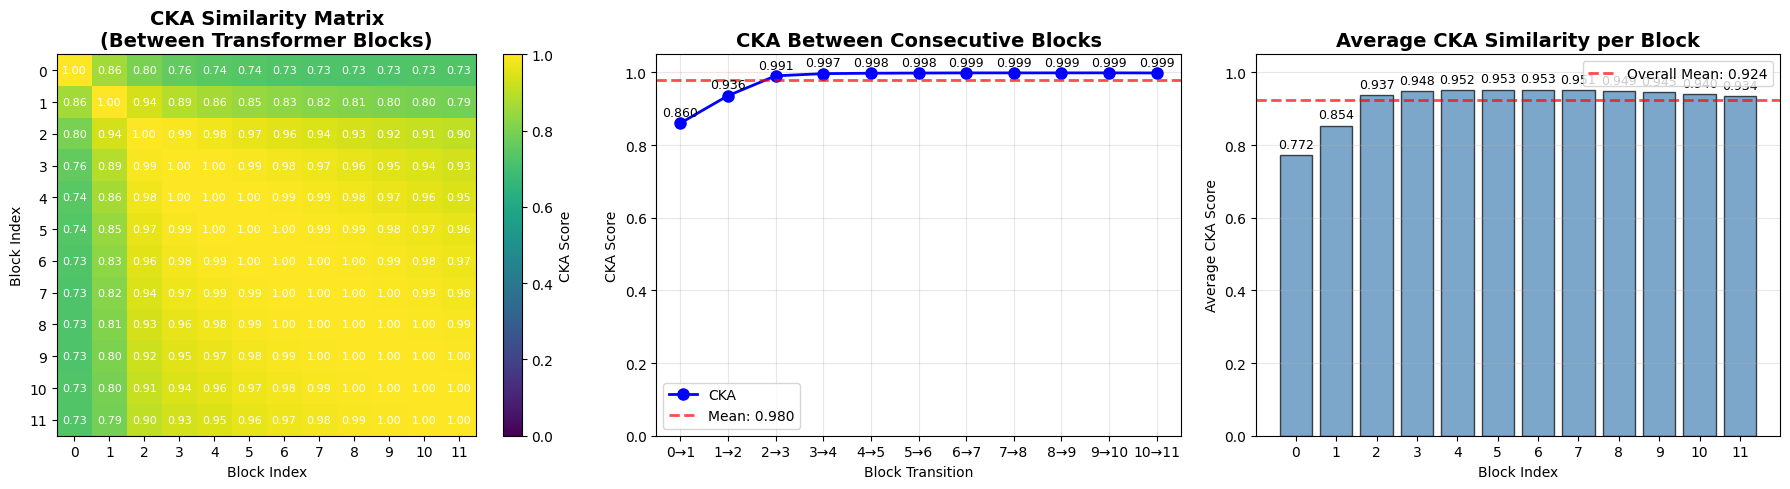


Analysis complete!

Interpretation Guide:
• High CKA (>0.8) between consecutive blocks:
  → Blocks learning very similar representations (potential redundancy)

• Medium CKA (0.5-0.8) between consecutive blocks:
  → Blocks refining representations while maintaining structure

• Low CKA (<0.5) between consecutive blocks:
  → Blocks learning distinct features (good differentiation)

• Decreasing CKA trend (early→late layers):
  → Hierarchical learning (basic → abstract features)

• Increasing CKA trend:
  → Representations converging to similar patterns


In [9]:
import torch
import torch.nn as nn
import os
import math
from contextlib import nullcontext
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from itertools import chain
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# Configuration
# ============================================================================
block_size = 128
batch_size = 8
eval_iters = 200

# ============================================================================
# CKA Implementation
# ============================================================================

class BatchwiseCKAComputer:
    """Compute CKA using streaming/batchwise updates."""
    def __init__(self, num_layers):
        self.num_layers = num_layers
        # Running sums for cross-covariance and self-covariance
        self.cross_cov = {}
        self.self_cov = {}
        self.n_samples = 0
        
    def update_batch(self, hidden_states):
        """
        hidden_states: list of tensors [batch_size, seq_len, hidden_dim]
        Flatten to [batch_size * seq_len, hidden_dim] for CKA computation
        """
        batch_size = hidden_states[0].shape[0]
        seq_len = hidden_states[0].shape[1]
        n = batch_size * seq_len
        
        # Flatten each layer's hidden states
        flattened = []
        for h in hidden_states:
            flattened.append(h.reshape(-1, h.shape[-1]))  # [n, d]
        
        # Update cross-covariance and self-covariance matrices
        for i in range(self.num_layers):
            for j in range(i, self.num_layers):
                key = (i, j)
                X = flattened[i]  # [n, d_i]
                Y = flattened[j]  # [n, d_j]
                
                # Compute gram matrices: K = X @ X.T, L = Y @ Y.T
                K = X @ X.T  # [n, n]
                L = Y @ Y.T  # [n, n]
                
                # HSIC = trace(K @ L)
                cross_hsic = torch.trace(K @ L).item()
                
                if key not in self.cross_cov:
                    self.cross_cov[key] = 0.0
                self.cross_cov[key] += cross_hsic
                
                # Self-covariance (for normalization)
                if i == j:
                    self_hsic = torch.trace(K @ K).item()
                    if i not in self.self_cov:
                        self.self_cov[i] = 0.0
                    self.self_cov[i] += self_hsic
        
        self.n_samples += n
    
    def compute_cka(self, i, j):
        """Compute CKA between layer i and j."""
        key = (min(i, j), max(i, j))
        if key not in self.cross_cov:
            return 0.0
        
        numerator = self.cross_cov[key]
        denominator = math.sqrt(self.self_cov[i] * self.self_cov[j])
        
        if denominator == 0:
            return 0.0
        
        return numerator / denominator
    
    def get_cka_matrix(self):
        """Return full CKA similarity matrix."""
        matrix = torch.zeros(self.num_layers, self.num_layers)
        for i in range(self.num_layers):
            for j in range(self.num_layers):
                matrix[i, j] = self.compute_cka(i, j)
        return matrix


# ============================================================================
# Data Loading
# ============================================================================

# Poor man's data loader
dataset = '/kaggle/input/wikitext/wikitext103'
data_dir = os.path.join('data', dataset)

def get_batch(split, device, device_type):
    """Load a batch of data from memmap files."""
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    
    if device_type == 'cuda':
        # Pin arrays x,y, which allows us to move them to GPU asynchronously
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    
    return x, y


# ============================================================================
# Model Loading and CKA Computation
# ============================================================================

# Model loading parameters
init_from = 'resume'
out_dir = './'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'

# Set device and dtype
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
device_type = 'cuda' if 'cuda' in device else 'cpu'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# # Load model
print(f"Loading model from {out_dir}...")
ckpt_path = '/kaggle/input/cka-models/pytorch/default/1/ckpt_best_learnable_scaling.pt' #'/kaggle/working/ckpt_best_learnable_scaling.pt' #'/kaggle/input/gpt-rezero/pytorch/default/1/ckpt_best.pt'
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])

model = GPT(gptconf)


# # model init
# model_args = dict(n_layer=12, n_head=12, n_embd=768, block_size=128,
#                   bias=False, vocab_size=50304, dropout=0.1) # start with model_args from command line
# gptconf = GPTConfig(**model_args)
# model = GPT(gptconf)


state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'
for k, v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Get model architecture info
num_blocks = model.config.n_layer  # Number of transformer blocks
hidden_size = model.config.n_embd
print(f"Model loaded: {num_blocks} transformer blocks, {hidden_size} hidden size")
print(f"Block size: {block_size}, Batch size: {batch_size}")
print(f"Will compute CKA for {num_blocks-1} consecutive block pairs")

# Initialize CKA computer for transformer blocks
cka_computer = BatchwiseCKAComputer(num_blocks)

# Process batches
print(f"\n{'='*70}")
print("Processing batches and computing CKA statistics...")
print(f"Collecting representations from {num_blocks} transformer blocks...")
print(f"Processing {eval_iters} iterations...")
print(f"{'='*70}\n")

total_loss = 0
total_tokens = 0

for k in tqdm(range(eval_iters), desc="Computing CKA"):
    X, Y = get_batch('train', device, device_type)
    
    with torch.no_grad():
        # Forward pass - collect hidden states after each block
        block_outputs = []
        x = X
        labels = Y
        
        # Get embedding (but don't include in CKA computation)
        tok_emb = model.transformer.wte(x)
        pos = torch.arange(0, x.size(1), dtype=torch.long, device=device)
        pos_emb = model.transformer.wpe(pos)
        x = model.transformer.drop(tok_emb + pos_emb)
        
        # Pass through transformer blocks and collect output after each block
        for block_idx, block in enumerate(model.transformer.h):
            x = block(x)
            # Store the output of this block on CPU to save GPU memory
            block_outputs.append(x.cpu())
        
        # Compute loss (no final LayerNorm in your model)
        logits = model.lm_head(x)
        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            labels.view(-1)
        )
        
        total_loss += loss.item() * x.numel()
        total_tokens += x.numel()
        
        # Update CKA statistics with block outputs
        cka_computer.update_batch(block_outputs)

# ============================================================================
# Results and Visualization
# ============================================================================

# Compute final results
print(f"\n{'='*70}")
print(f"Processed {eval_iters} batches with {cka_computer.n_samples} total samples")
print(f"Total tokens processed: {total_tokens}")

# Compute perplexity
average_loss = total_loss / total_tokens
perplexity = math.exp(average_loss)
print(f"Average loss: {average_loss:.4f}")
print(f"Perplexity on WikiText-103: {perplexity:.4f}")

# Get CKA results between consecutive blocks
print(f"\n{'='*70}")
print(f"CKA Scores (consecutive transformer blocks):")
print(f"{'='*70}")
cka_scores = []
for i in range(num_blocks - 1):
    cka_score = cka_computer.compute_cka(i, i + 1)
    cka_scores.append(cka_score)
    print(f"Block {i} → Block {i+1}: {cka_score:.4f}")

# Get full CKA matrix
cka_matrix = cka_computer.get_cka_matrix()

# Print some additional statistics
print(f"\n{'='*70}")
print("Additional CKA Statistics:")
print(f"{'='*70}")
print(f"Average consecutive block CKA: {np.mean(cka_scores):.4f}")
print(f"Min consecutive block CKA: {np.min(cka_scores):.4f}")
print(f"Max consecutive block CKA: {np.max(cka_scores):.4f}")
print(f"Std consecutive block CKA: {np.std(cka_scores):.4f}")

# Check similarity between first and last block
first_last_cka = cka_computer.compute_cka(0, num_blocks - 1)
print(f"\nFirst-to-Last block CKA (Block 0 → Block {num_blocks-1}): {first_last_cka:.4f}")

# Additional interesting comparisons
print(f"\n{'='*70}")
print("Additional Block Comparisons:")
print(f"{'='*70}")
if num_blocks >= 3:
    print(f"Block 0 → Block 2: {cka_computer.compute_cka(0, 2):.4f}")
if num_blocks >= 4:
    print(f"Block 0 → Block 3: {cka_computer.compute_cka(0, 3):.4f}")
if num_blocks >= 6:
    print(f"Block 1 → Block 5: {cka_computer.compute_cka(1, 5):.4f}")
    print(f"Block 2 → Block 5: {cka_computer.compute_cka(2, 5):.4f}")

# Plotting
print(f"\n{'='*70}")
print("Generating visualizations...")
print(f"{'='*70}\n")

fig = plt.figure(figsize=(18, 5))

# Plot 1: CKA Matrix
ax1 = plt.subplot(1, 3, 1)
im1 = ax1.imshow(cka_matrix.numpy(), cmap='viridis', aspect='auto', vmin=0, vmax=1)
cbar1 = plt.colorbar(im1, ax=ax1, label='CKA Score')
ax1.set_title("CKA Similarity Matrix\n(Between Transformer Blocks)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Block Index")
ax1.set_ylabel("Block Index")
ax1.set_xticks(range(num_blocks))
ax1.set_yticks(range(num_blocks))

# Add text annotations to the heatmap
for i in range(num_blocks):
    for j in range(num_blocks):
        text = ax1.text(j, i, f'{cka_matrix[i, j].item():.2f}',
                       ha="center", va="center", color="white", fontsize=8)

# Plot 2: Consecutive block comparisons
ax2 = plt.subplot(1, 3, 2)
block_pairs = [f"{i}→{i+1}" for i in range(len(cka_scores))]
x_pos = range(len(cka_scores))

ax2.plot(x_pos, cka_scores, 'b-o', label='CKA', linewidth=2, markersize=8)
ax2.axhline(y=np.mean(cka_scores), color='r', linestyle='--', 
            label=f'Mean: {np.mean(cka_scores):.3f}', alpha=0.7, linewidth=2)
ax2.set_title("CKA Between Consecutive Blocks", fontsize=14, fontweight='bold')
ax2.set_xlabel("Block Transition")
ax2.set_ylabel("CKA Score")
ax2.legend(fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(block_pairs, rotation=0, ha='center')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

# Add value labels on the points
for i, score in enumerate(cka_scores):
    ax2.text(i, score + 0.02, f'{score:.3f}', ha='center', fontsize=9)

# Plot 3: Layer-wise average similarity
ax3 = plt.subplot(1, 3, 3)
avg_similarity = cka_matrix.mean(dim=1).numpy()
bars = ax3.bar(range(num_blocks), avg_similarity, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axhline(y=np.mean(avg_similarity), color='r', linestyle='--', 
            label=f'Overall Mean: {np.mean(avg_similarity):.3f}', alpha=0.7, linewidth=2)
ax3.set_title("Average CKA Similarity per Block", fontsize=14, fontweight='bold')
ax3.set_xlabel("Block Index")
ax3.set_ylabel("Average CKA Score")
ax3.set_xticks(range(num_blocks))
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1.05])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, avg_similarity)):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
             f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('block_cka_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'block_cka_analysis.png'")
plt.show()

print(f"\n{'='*70}")
print("Analysis complete!")
print(f"{'='*70}")
print("\nInterpretation Guide:")
print("=" * 70)
print("• High CKA (>0.8) between consecutive blocks:")
print("  → Blocks learning very similar representations (potential redundancy)")
print("\n• Medium CKA (0.5-0.8) between consecutive blocks:")
print("  → Blocks refining representations while maintaining structure")
print("\n• Low CKA (<0.5) between consecutive blocks:")
print("  → Blocks learning distinct features (good differentiation)")
print("\n• Decreasing CKA trend (early→late layers):")
print("  → Hierarchical learning (basic → abstract features)")
print("\n• Increasing CKA trend:")
print("  → Representations converging to similar patterns")
print("=" * 70)

In [12]:
import torch
import torch.nn as nn
import copy
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================================
# Layer Removal Functions
# ============================================================================

def identify_redundant_layers(cka_scores, threshold=0.95):
    """
    Identify layers to remove based on CKA threshold.
    Returns indices of layers that should be removed (the second layer in high-CKA pairs).
    
    Args:
        cka_scores: list of CKA scores between consecutive blocks
        threshold: CKA threshold above which layers are considered redundant
    
    Returns:
        list of layer indices to remove
    """
    layers_to_remove = []
    for i, score in enumerate(cka_scores):
        if score >= threshold:
            # Remove the second layer in the pair (i+1)
            layers_to_remove.append(i + 1)
    
    return sorted(list(set(layers_to_remove)))


def remove_layers_from_model(model, layers_to_remove):
    """
    Create a new model with specified layers removed.
    
    Args:
        model: original GPT model
        layers_to_remove: list of block indices to remove
    
    Returns:
        new model with layers removed
    """
    # Create a deep copy of the model
    new_model = copy.deepcopy(model)
    
    # Get the original blocks
    original_blocks = list(new_model.transformer.h)
    
    # Create new block list without the removed layers
    new_blocks = [block for i, block in enumerate(original_blocks) 
                  if i not in layers_to_remove]
    
    # Replace the module list
    new_model.transformer.h = nn.ModuleList(new_blocks)
    
    # Update config
    new_model.config.n_layer = len(new_blocks)
    
    return new_model


def evaluate_perplexity(model, device, device_type, ctx, eval_iters=200):
    """
    Evaluate perplexity on validation set.
    
    Args:
        model: model to evaluate
        device: device to run on
        device_type: 'cuda' or 'cpu'
        ctx: autocast context
        eval_iters: number of evaluation iterations
    
    Returns:
        perplexity, average_loss
    """
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for k in tqdm(range(eval_iters), desc="Evaluating", leave=False):
            X, Y = get_batch('val', device, device_type)
            
            with ctx:
                # Forward pass
                tok_emb = model.transformer.wte(X)
                pos = torch.arange(0, X.size(1), dtype=torch.long, device=device)
                pos_emb = model.transformer.wpe(pos)
                x = model.transformer.drop(tok_emb + pos_emb)
                
                # Pass through remaining blocks
                for block in model.transformer.h:
                    x = block(x)
                
                # Compute loss
                logits = model.lm_head(x)
                loss = nn.functional.cross_entropy(
                    logits.view(-1, logits.size(-1)), 
                    Y.view(-1)
                )
                
                total_loss += loss.item() * X.numel()
                total_tokens += X.numel()
    
    average_loss = total_loss / total_tokens
    perplexity = np.exp(average_loss)
    
    return perplexity, average_loss


# ============================================================================
# Main Analysis: Remove Layers and Measure Degradation
# ============================================================================

print(f"\n{'='*80}")
print("LAYER REMOVAL ANALYSIS")
print(f"{'='*80}\n")

# Define different CKA thresholds to test
thresholds = [ 0.99]

# Store results
results = []

# Baseline: Evaluate original model
print("Evaluating baseline model (no layers removed)...")
baseline_perplexity, baseline_loss = evaluate_perplexity(
    model, device, device_type, ctx, eval_iters=eval_iters
)
print(f"✓ Baseline Perplexity: {baseline_perplexity:.4f}")
print(f"✓ Baseline Loss: {baseline_loss:.4f}")

results.append({
    'threshold': 'baseline',
    'layers_removed': [],
    'num_removed': 0,
    'remaining_layers': num_blocks,
    'perplexity': baseline_perplexity,
    'loss': baseline_loss,
    'perplexity_increase': 0.0,
    'relative_increase': 0.0
})

print(f"\n{'-'*80}\n")

# Test different thresholds
for threshold in thresholds:
    print(f"Testing CKA threshold: {threshold}")
    print(f"{'-'*80}")
    
    # Identify layers to remove
    layers_to_remove = identify_redundant_layers(cka_scores, threshold=threshold)
    #layers_to_remove = [3,4,5,6,7,8,9,10]
    if len(layers_to_remove) == 0:
        print(f"  No layers exceed CKA threshold of {threshold}")
        print()
        continue
    
    print(f"  Layers to remove: {layers_to_remove}")
    print(f"  Number of layers to remove: {len(layers_to_remove)}/{num_blocks}")
    
    # Create model with layers removed
    print(f"  Creating model with {len(layers_to_remove)} layers removed...")
    pruned_model = remove_layers_from_model(model, layers_to_remove)
    pruned_model = pruned_model.to(device)
    
    # Evaluate pruned model
    print(f"  Evaluating pruned model...")
    pruned_perplexity, pruned_loss = evaluate_perplexity(
        pruned_model, device, device_type, ctx, eval_iters=eval_iters
    )
    
    # Calculate degradation
    perplexity_increase = pruned_perplexity - baseline_perplexity
    relative_increase = (perplexity_increase / baseline_perplexity) * 100
    
    print(f"  ✓ Pruned Perplexity: {pruned_perplexity:.4f}")
    print(f"  ✓ Pruned Loss: {pruned_loss:.4f}")
    print(f"  ✓ Perplexity Increase: {perplexity_increase:.4f} ({relative_increase:.2f}%)")
    print()
    
    # Store results
    results.append({
        'threshold': threshold,
        'layers_removed': layers_to_remove,
        'num_removed': len(layers_to_remove),
        'remaining_layers': num_blocks - len(layers_to_remove),
        'perplexity': pruned_perplexity,
        'loss': pruned_loss,
        'perplexity_increase': perplexity_increase,
        'relative_increase': relative_increase
    })
    
    # Free memory
    del pruned_model
    torch.cuda.empty_cache()

# ============================================================================
# Results Summary
# ============================================================================

print(f"\n{'='*80}")
print("RESULTS SUMMARY")
print(f"{'='*80}\n")

# Create summary table
print(f"{'Threshold':<12} {'Removed':<10} {'Remaining':<12} {'Perplexity':<14} {'Increase':<14} {'Relative %':<12}")
print(f"{'-'*80}")

for result in results:
    threshold_str = 'Baseline' if result['threshold'] == 'baseline' else f"{result['threshold']:.2f}"
    print(f"{threshold_str:<12} {result['num_removed']:<10} {result['remaining_layers']:<12} "
          f"{result['perplexity']:<14.4f} {result['perplexity_increase']:<14.4f} {result['relative_increase']:<12.2f}")

print(f"{'-'*80}\n")




LAYER REMOVAL ANALYSIS

Evaluating baseline model (no layers removed)...


✓ Baseline Perplexity: 99.6243
✓ Baseline Loss: 4.6014

--------------------------------------------------------------------------------

Testing CKA threshold: 0.99
--------------------------------------------------------------------------------
  Layers to remove: [3, 4, 5, 6, 7, 8, 9, 10, 11]
  Number of layers to remove: 9/12
  Creating model with 9 layers removed...
  Evaluating pruned model...


  ✓ Pruned Perplexity: 507.2139
  ✓ Pruned Loss: 6.2289
  ✓ Perplexity Increase: 407.5895 (409.13%)


RESULTS SUMMARY

Threshold    Removed    Remaining    Perplexity     Increase       Relative %  
--------------------------------------------------------------------------------
Baseline     0          12           99.6243        0.0000         0.00        
0.99         9          3            507.2139       407.5895       409.13      
--------------------------------------------------------------------------------



In [13]:
# Extract learned alphas from the model
for i, block in enumerate(model.transformer.h):
    alpha1 = block.res_alpha_1   # or however you stored it
    alpha2 = block.res_alpha_2
    print(f"Layer {i}: alpha1 = {alpha1.item():.4f}")
    print(f"Layer {i}: alpha2 = {alpha2.item():.4f}")

Layer 0: alpha1 = -0.0290
Layer 0: alpha2 = -0.7261
Layer 1: alpha1 = -0.3636
Layer 1: alpha2 = 0.7437
Layer 2: alpha1 = 0.5249
Layer 2: alpha2 = 0.4667
Layer 3: alpha1 = -0.2888
Layer 3: alpha2 = -0.2851
Layer 4: alpha1 = -0.0799
Layer 4: alpha2 = -0.1895
Layer 5: alpha1 = 0.0996
Layer 5: alpha2 = 0.1431
Layer 6: alpha1 = 0.0834
Layer 6: alpha2 = 0.1192
Layer 7: alpha1 = -0.0661
Layer 7: alpha2 = 0.1059
Layer 8: alpha1 = -0.0475
Layer 8: alpha2 = -0.0950
Layer 9: alpha1 = -0.0458
Layer 9: alpha2 = 0.0870
Layer 10: alpha1 = -0.0562
Layer 10: alpha2 = -0.0774
Layer 11: alpha1 = 0.0407
Layer 11: alpha2 = 0.0641


In [1]:
# GPT model with LayerDrop implementation
import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a single linear
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        # self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        self.flash = False
        if not self.flash:
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True
            )
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v  # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = y.transpose(1, 2).contiguous().view(B, T, C)  # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):
    """
    Transformer block WITH Pre-LayerNorm and optional LayerDrop.
    Each residual branch is scaled by a fixed factor alpha.
    """

    def __init__(self, config):
        super().__init__()
        self.attn = CausalSelfAttention(config)
        self.mlp = MLP(config)

        # --- Added: Pre-LayerNorm for attention and MLP ---
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.ln_2 = nn.LayerNorm(config.n_embd)

        # fixed scaling factor (not learnable)
        self.scale = 1.0 / 1.0  # Change to 1.0 / math.sqrt(config.n_layer) for scaled version
        
        # LayerDrop probability
        self.layer_drop_prob = config.layer_drop_prob

    def forward(self, x):
        # LayerDrop: randomly skip entire block during training
        if self.training and self.layer_drop_prob > 0:
            if torch.rand(1).item() < self.layer_drop_prob:
                # Skip this entire block (return input unchanged)
                return x
        
        # Normal forward pass
        # Pre-LN attention
        x = x + self.scale * self.attn(self.ln_1(x))

        # Pre-LN MLP
        x = x + self.scale * self.mlp(self.ln_2(x))

        return x


class BlockWithSubLayerDrop(nn.Module):
    """
    Alternative implementation: Drop attention and MLP sublayers independently.
    This is more fine-grained than dropping entire blocks.
    """

    def __init__(self, config):
        super().__init__()
        self.attn = CausalSelfAttention(config)
        self.mlp = MLP(config)

        # --- Added: Pre-LayerNorm for attention and MLP ---
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.ln_2 = nn.LayerNorm(config.n_embd)

        # fixed scaling factor (not learnable)
        self.scale = 1.0 / 1.0  # Change to 1.0 / math.sqrt(config.n_layer) for scaled version
        
        # LayerDrop probability for each sublayer
        self.layer_drop_prob = config.layer_drop_prob

    def forward(self, x):
        # LayerDrop for attention sublayer
        if self.training and self.layer_drop_prob > 0:
            if torch.rand(1).item() >= self.layer_drop_prob:
                x = x + self.scale * self.attn(self.ln_1(x))
            # else: skip attention sublayer
        else:
            # Inference: always use attention
            x = x + self.scale * self.attn(self.ln_1(x))

        # LayerDrop for MLP sublayer
        if self.training and self.layer_drop_prob > 0:
            if torch.rand(1).item() >= self.layer_drop_prob:
                x = x + self.scale * self.mlp(self.ln_2(x))
            # else: skip MLP sublayer
        else:
            # Inference: always use MLP
            x = x + self.scale * self.mlp(self.ln_2(x))

        return x
@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304  # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 6
    n_head: int = 8
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True  # True: bias in Linears, False: faster slightly
    layer_drop_prob: float = 0.0  # LayerDrop probability (0.0 = no LayerDrop, 0.1 = 10% drop rate)
    use_sublayer_drop: bool = False  # If True, use BlockWithSubLayerDrop instead of Block


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        # Choose block type based on config
        BlockClass = BlockWithSubLayerDrop if config.use_sublayer_drop else Block

        # transformer modules
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([BlockClass(config) for _ in range(config.n_layer)]),
            # NOTE: removed ln_f (final LayerNorm) entirely (kept that choice minimal)
        ))
        # language model head
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight tying: share token embedding and lm_head weights
        # this keeps behavior similar to original GPT implementations
        self.transformer.wte.weight = self.lm_head.weight

        # init all weights (base)
        self.apply(self._init_weights)

        # -------------------------
        # Minimal FixUp-style edits
        # 1) initialize final projection weights of residual branches with std = L**(-0.75)
        # 2) zero-init biases of final projections if present
        # This prevents the model from cancelling the fixed residual scale alpha via large initial residuals.
        # -------------------------
        L = max(1, config.n_layer)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                # FixUp-style scaled init for final projection of each branch
                torch.nn.init.normal_(p, mean=0.0, std=(L ** (-0.75)))
            if pn.endswith('c_proj.bias'):
                # zero biases for stability (if bias exists)
                with torch.no_grad():
                    p.zero_()

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params() / 1e6,))
        if config.layer_drop_prob > 0:
            drop_type = "sublayer" if config.use_sublayer_drop else "block"
            print(f"LayerDrop enabled: p={config.layer_drop_prob} ({drop_type} level)")

    def get_num_params(self, non_embedding=True):
        """
        Return number of parameters. If non_embedding=True subtract position embeddings
        to match many published counts.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        """
        idx: (b, t) long tensor of token indices
        targets: (b, t) long tensor for computing cross-entropy loss (optional)
        """
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device)  # shape (t)

        # token + position embeddings
        tok_emb = self.transformer.wte(idx)  # (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos)  # (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)

        # forward through transformer blocks (pre-LN)
        # LayerDrop happens inside each block's forward method
        for block in self.transformer.h:
            x = block(x)

        # no final LayerNorm (ln_f) is applied (kept minimal per request)

        if targets is not None:
            # full logits for loss computation
            logits = self.lm_head(x)  # (b, t, vocab)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # during inference, only compute logits for last token to save compute
            logits = self.lm_head(x[:, [-1], :])  # (b, 1, vocab)
            loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        """
        Reduce block size (positional embeddings and attention mask) for memory savings.
        """
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:, :, :block_size, :block_size]

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        """
        Minimal change: use a smaller learning rate for transformer block parameters so that
        the optimizer does not trivially amplify residual branch weights and cancel the effect of alpha.
        Block params (inside transformer.h) get lr = base_lr / sqrt(L). Other params use base_lr.
        """
        L = max(1, self.config.n_layer)
        lr_block = learning_rate / math.sqrt(L)
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}

        # split parameters into block params (transformer.h.*) and others
        block_decay = []
        block_nodecay = []
        other_decay = []
        other_nodecay = []

        for n, p in param_dict.items():
            is_block = n.split('.')[0] == 'transformer' and ('.h.' in n)
            # treat bias and 1-d tensors as no-decay per common practice
            if is_block:
                if p.dim() >= 2:
                    block_decay.append(p)
                else:
                    block_nodecay.append(p)
            else:
                if p.dim() >= 2:
                    other_decay.append(p)
                else:
                    other_nodecay.append(p)

        optim_groups = [
            {'params': block_decay, 'weight_decay': weight_decay, 'lr': lr_block},
            {'params': block_nodecay, 'weight_decay': 0.0, 'lr': lr_block},
            {'params': other_decay, 'weight_decay': weight_decay, 'lr': learning_rate},
            {'params': other_nodecay, 'weight_decay': 0.0, 'lr': learning_rate},
        ]

        # choose fused AdamW when available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, eps=1e-4, **extra_args)
        print(f"using fused AdamW: {use_fused}")
        print(f"block lr: {lr_block:.3e}, other lr: {learning_rate:.3e}")
        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd // cfg.n_head, cfg.block_size
        flops_per_token = 6 * N + 12 * L * H * Q * T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        flops_achieved = flops_per_iter * (1.0 / dt)
        flops_promised = 312e12  # A100 bfloat16 peak flops ~312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        autoregressive generation: append tokens to idx max_new_tokens times
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
"""
This training script can be run both on a single gpu in debug mode,
and also in a larger training run with distributed data parallel (ddp).

To run on a single GPU, example:
$ python train.py --batch_size=32 --compile=False

To run with DDP on 4 gpus on 1 node, example:
$ torchrun --standalone --nproc_per_node=4 train.py

To run with DDP on 4 gpus across 2 nodes, example:
- Run on the first (master) node with example IP 123.456.123.456:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=0 --master_addr=123.456.123.456 --master_port=1234 train.py
- Run on the worker node:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=1 --master_addr=123.456.123.456 --master_port=1234 train.py
(If your cluster does not have Infiniband interconnect prepend NCCL_IB_DISABLE=1)
"""

import os
import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

#from model import GPTConfig, GPT

# -----------------------------------------------------------------------------
# default config values designed to train a gpt2 (124M) on OpenWebText
# I/O
out_dir = './'
eval_interval = 200
log_interval = 1
eval_iters = 200
eval_only = False # if True, script exits right after the first eval
always_save_checkpoint = True # if True, always save a checkpoint after each eval
init_from = 'scratch' # 'scratch' or 'resume' or 'gpt2*'
# wandb logging
wandb_log = False # disabled by default
wandb_project = 'ts'
wandb_run_name = 'gpt2' # 'run' + str(time.time())
# data
dataset = '/kaggle/input/wikitext/wikitext103' 
gradient_accumulation_steps = 2 # used to simulate larger batch sizes
batch_size = 16 # if gradient_accumulation_steps > 1, this is the micro-batch size  #1801350/160=11258 batches
block_size = 256
# model
n_layer = 12
n_head = 12
n_embd =  768
dropout = 0.1 # for pretraining 0 is good, for finetuning try 0.1+
bias = False # do we use bias inside LayerNorm and Linear layers?
# adamw optimizer
learning_rate = 5e-4 # max learning rate
max_iters = 10000 # total number of training iterations
weight_decay = 0.01
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
# learning rate decay settings
decay_lr = True # whether to decay the learning rate
warmup_iters = 2000 # how many steps to warm up for
lr_decay_iters = 20000 # should be ~= max_iters per Chinchilla
min_lr = 5e-6 # minimum learning rate, should be ~= learning_rate/10 per Chinchilla


layer_drop_prob=0.1,  # 10% drop rate


# DDP settings
backend = 'nccl' # 'nccl', 'gloo', etc.
# system
device = 'cuda' # examples: 'cpu', 'cuda', 'cuda:0', 'cuda:1' etc., or try 'mps' on macbooks
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
compile = False # use PyTorch 2.0 to compile the model to be faster
# # -----------------------------------------------------------------------------
# config_keys = [k for k,v in globals().items() if not k.startswith('_') and isinstance(v, (int, float, bool, str))]
# exec(open('configurator.py').read()) # overrides from command line or config file
# config = {k: globals()[k] for k in config_keys} # will be useful for logging
# -----------------------------------------------------------------------------

# various inits, derived attributes, I/O setup
ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
if ddp:
    init_process_group(backend=backend)
    ddp_rank = int(os.environ['RANK'])
    ddp_local_rank = int(os.environ['LOCAL_RANK'])
    ddp_world_size = int(os.environ['WORLD_SIZE'])
    device = f'cuda:{ddp_local_rank}'
    torch.cuda.set_device(device)
    master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
    seed_offset = ddp_rank # each process gets a different seed
    # world_size number of processes will be training simultaneously, so we can scale
    # down the desired gradient accumulation iterations per process proportionally
    assert gradient_accumulation_steps % ddp_world_size == 0
    gradient_accumulation_steps //= ddp_world_size
else:
    # if not ddp, we are running on a single gpu, and one process
    master_process = True
    seed_offset = 0
    ddp_world_size = 1
tokens_per_iter = gradient_accumulation_steps * ddp_world_size * batch_size * block_size
print(f"tokens per iteration will be: {tokens_per_iter:,}")

if master_process:
    os.makedirs(out_dir, exist_ok=True)
torch.manual_seed(1337 + seed_offset)
torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# poor man's data loader
data_dir = os.path.join('data', dataset)
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

# init these up here, can override if init_from='resume' (i.e. from a checkpoint)
iter_num = 0
best_val_loss = 1e9

# attempt to derive vocab_size from the dataset
meta_path = os.path.join(data_dir, 'meta.pkl')
meta_vocab_size = None
if os.path.exists(meta_path):
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    meta_vocab_size = meta['vocab_size']
    print(f"found vocab_size = {meta_vocab_size} (inside {meta_path})")

# model init
model_args = dict(n_layer=n_layer, n_head=n_head, n_embd=n_embd, block_size=block_size,
                  bias=bias, vocab_size=None, dropout=dropout,layer_drop_prob=0.1) # start with model_args from command line
if init_from == 'scratch':
    # init a new model from scratch
    print("Initializing a new model from scratch")
    # determine the vocab size we'll use for from-scratch training
    if meta_vocab_size is None:
        print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
    model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304
    gptconf = GPTConfig(**model_args)
    print(gptconf)
    model = GPT(gptconf)
    
elif init_from == 'resume':
    print(f"Resuming training from {out_dir}")
    # resume training from a checkpoint.
    ckpt_path = os.path.join(out_dir, 'ckpt.pt')
    checkpoint = torch.load(ckpt_path, map_location=device)
    checkpoint_model_args = checkpoint['model_args']
    # force these config attributes to be equal otherwise we can't even resume training
    # the rest of the attributes (e.g. dropout) can stay as desired from command line
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = checkpoint_model_args[k]
    # create the model
    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)
    state_dict = checkpoint['model']
    # fix the keys of the state dictionary :(
    # honestly no idea how checkpoints sometimes get this prefix, have to debug more
    unwanted_prefix = '_orig_mod.'
    for k,v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    model.load_state_dict(state_dict)
    iter_num = checkpoint['iter_num']
    best_val_loss = checkpoint['best_val_loss']
elif init_from.startswith('gpt2'):
    print(f"Initializing from OpenAI GPT-2 weights: {init_from}")
    # initialize from OpenAI GPT-2 weights
    override_args = dict(dropout=dropout)
    model = GPT.from_pretrained(init_from, override_args)
    # read off the created config params, so we can store them into checkpoint correctly
    for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
        model_args[k] = getattr(model.config, k)
# crop down the model block size if desired, using model surgery
if block_size < model.config.block_size:
    model.crop_block_size(block_size)
    model_args['block_size'] = block_size # so that the checkpoint will have the right value
model.to(device)

# initialize a GradScaler. If enabled=False scaler is a no-op
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

# optimizer
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
if init_from == 'resume':
    optimizer.load_state_dict(checkpoint['optimizer'])
checkpoint = None # free up memory

# compile the model
if compile:
    print("compiling the model... (takes a ~minute)")
    unoptimized_model = model
    model = torch.compile(model) # requires PyTorch 2.0

# wrap model into DDP container
if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])

# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with ctx:
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()  # convert to Python float
    # Check for NaNs after both splits have been computed
    if math.isnan(out['train']) or math.isnan(out['val']):
        print("NaN detected in train or val loss:", out)
    print(out)
    model.train()
    return out


# learning rate decay scheduler (cosine with warmup)
def get_lr(it):
    # 1) linear warmup for warmup_iters steps
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2) if it > lr_decay_iters, return min learning rate
    if it > lr_decay_iters:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
    return min_lr + coeff * (learning_rate - min_lr)

# logging
if wandb_log and master_process:
    import wandb
    wandb.init(project=wandb_project, name=wandb_run_name, config=config)

# training loop
X, Y = get_batch('train') # fetch the very first batch
t0 = time.time()
local_iter_num = 0 # number of iterations in the lifetime of this process
raw_model = model.module if ddp else model # unwrap DDP container if needed
running_mfu = -1.0


save_interval = 20000  # Save every 20,000 iterations
while True:
    # determine and set the learning rate for this iteration
    lr = get_lr(iter_num) if decay_lr else learning_rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # ---- Evaluate periodically ----
    if iter_num % eval_interval == 0 and master_process:
        losses = estimate_loss()
        print(f"Step {iter_num}: train {losses['train']:.4f}, val {losses['val']:.4f}")

        # # (1) Save checkpoint every N iterations
        # if iter_num % save_interval == 0:
        #     ckpt_path = os.path.join(out_dir, f"ckpt_it{iter_num}.pt")
        #     ckpt = {
        #         'model': raw_model.state_dict(),
        #         'optimizer': optimizer.state_dict(),
        #         'model_args': model_args,
        #         'iter_num': iter_num,
        #         'best_val_loss': best_val_loss,
        #     }
        #     torch.save(ckpt, ckpt_path)
        #     print(f"Periodic checkpoint saved to {ckpt_path}")

        # (2) Save best-loss checkpoint
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            ckpt_path = os.path.join(out_dir, "ckpt_layer_drop_best.pt")
            ckpt = {
                'model': raw_model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'model_args': model_args,
                'iter_num': iter_num,
                'best_val_loss': best_val_loss,
            }
            torch.save(ckpt, ckpt_path)
            print(f"🏆 New best model saved to {ckpt_path} (val loss: {best_val_loss:.4f})")

        

    # ---- Exit early for eval-only ----
    if iter_num == 0 and eval_only:
        break
    

    # forward backward update, with optional gradient accumulation to simulate larger batch size
    # and using the GradScaler if data type is float16
    for micro_step in range(gradient_accumulation_steps):
        if ddp:
            # in DDP training we only need to sync gradients at the last micro step.
            # the official way to do this is with model.no_sync() context manager, but
            # I really dislike that this bloats the code and forces us to repeat code
            # looking at the source of that context manager, it just toggles this variable
            model.require_backward_grad_sync = (micro_step == gradient_accumulation_steps - 1)
        with ctx:
            logits, loss = model(X, Y)
            loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
        # immediately async prefetch next batch while model is doing the forward pass on the GPU
        X, Y = get_batch('train')
        # backward pass, with gradient scaling if training in fp16
        scaler.scale(loss).backward()
    # clip the gradient
    if grad_clip != 0.0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    # step the optimizer and scaler if training in fp16
    scaler.step(optimizer)
    scaler.update()
    # flush the gradients as soon as we can, no need for this memory anymore
    optimizer.zero_grad(set_to_none=True)

    # # timing and logging
    # t1 = time.time()
    # dt = t1 - t0
    # t0 = t1
    # if iter_num % log_interval == 0 and master_process:
    #     # get loss as float. note: this is a CPU-GPU sync point
    #     # scale up to undo the division above, approximating the true total loss (exact would have been a sum)
    #     lossf = loss.item() * gradient_accumulation_steps
    #     if local_iter_num >= 5: # let the training loop settle a bit
    #         mfu = raw_model.estimate_mfu(batch_size * gradient_accumulation_steps, dt)
    #         running_mfu = mfu if running_mfu == -1.0 else 0.9*running_mfu + 0.1*mfu
    #     print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")
    iter_num += 1
    local_iter_num += 1

    # termination conditions
    if iter_num > max_iters:
        break

if ddp:
    destroy_process_group()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wikitext/wikitext103/train.bin
/kaggle/input/wikitext/wikitext103/validation.bin
/kaggle/input/wikitext/wikitext103/prepare_wikitext103.ipynb
/kaggle/input/wikitext/wikitext103/prepare_wikitext103.py
/kaggle/input/wikitext/wikitext103/val.bin
/kaggle/input/wikitext/wikitext103/.ipynb_checkpoints/prepare_wikitext103-checkpoint.ipynb
/kaggle/input/cka-models/pytorch/default/1/ckpt_best_learnable_scaling.pt
/kaggle/input/cka-models/pytorch/default/1/ckpt_best_sqrt_L_scaling.pt
/kaggle/input/cka-models/pytorch/default/1/ckpt_best_no_scaling.pt
tokens per iteration will be: 8,192
Initializing a new model from scratch
defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)
GPTConfig(block_size=256, vocab_size=50304, n_layer=12, n_head=12, n_embd=768, dropout=0.1, bias=False, layer_drop_prob=0.1, use_sublayer_drop=False)
number of parameters: 123.60M
LayerDrop enabled: p=0.1 (block level)
using fused AdamW: True
block lr: 1.443e-04, other lr: 5.000e-04


/tmp/ipykernel_47/1713791859.py:218: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


{'train': 28.824892044067383, 'val': 28.81097412109375}
Step 0: train 28.8249, val 28.8110
🏆 New best model saved to ./ckpt_layer_drop_best.pt (val loss: 28.8110)
{'train': 10.40117073059082, 'val': 10.434178352355957}
Step 200: train 10.4012, val 10.4342
🏆 New best model saved to ./ckpt_layer_drop_best.pt (val loss: 10.4342)
{'train': 8.794051170349121, 'val': 8.784882545471191}
Step 400: train 8.7941, val 8.7849
🏆 New best model saved to ./ckpt_layer_drop_best.pt (val loss: 8.7849)
{'train': 8.475386619567871, 'val': 8.508434295654297}
Step 600: train 8.4754, val 8.5084
🏆 New best model saved to ./ckpt_layer_drop_best.pt (val loss: 8.5084)
{'train': 7.873193264007568, 'val': 7.884285926818848}
Step 800: train 7.8732, val 7.8843
🏆 New best model saved to ./ckpt_layer_drop_best.pt (val loss: 7.8843)
{'train': 7.567811489105225, 'val': 7.562783718109131}
Step 1000: train 7.5678, val 7.5628
🏆 New best model saved to ./ckpt_layer_drop_best.pt (val loss: 7.5628)
{'train': 7.243284702301025

Loading model from ./...
number of parameters: 123.60M
LayerDrop enabled: p=0.1 (block level)
Model loaded: 12 transformer blocks, 768 hidden size
Block size: 128, Batch size: 8
Will compute CKA for 11 consecutive block pairs

Processing batches and computing CKA statistics...
Processing 200 iterations...



Computing CKA: 100%|██████████| 200/200 [06:38<00:00,  1.99s/it]



Processed 200 batches with 204800 total samples
Total tokens processed: 157286400
Average loss: 4.3609
Perplexity on WikiText-103: 78.3241

CKA Scores (consecutive transformer blocks):
Block 0 → Block 1: 0.9671
Block 1 → Block 2: 0.9857
Block 2 → Block 3: 0.9920
Block 3 → Block 4: 0.9927
Block 4 → Block 5: 0.9932
Block 5 → Block 6: 0.9935
Block 6 → Block 7: 0.9931
Block 7 → Block 8: 0.9902
Block 8 → Block 9: 0.9859
Block 9 → Block 10: 0.9862
Block 10 → Block 11: 0.9963

Additional CKA Statistics:
Average consecutive block CKA: 0.9887
Min consecutive block CKA: 0.9671
Max consecutive block CKA: 0.9963
Std consecutive block CKA: 0.0076

First-to-Last block CKA (Block 0 → Block 11): 0.2821

Additional Block Comparisons:
Block 0 → Block 2: 0.9150
Block 0 → Block 3: 0.8638
Block 1 → Block 5: 0.8700
Block 2 → Block 5: 0.9358

Generating visualizations...

Visualization saved as 'block_cka_analysis.png'


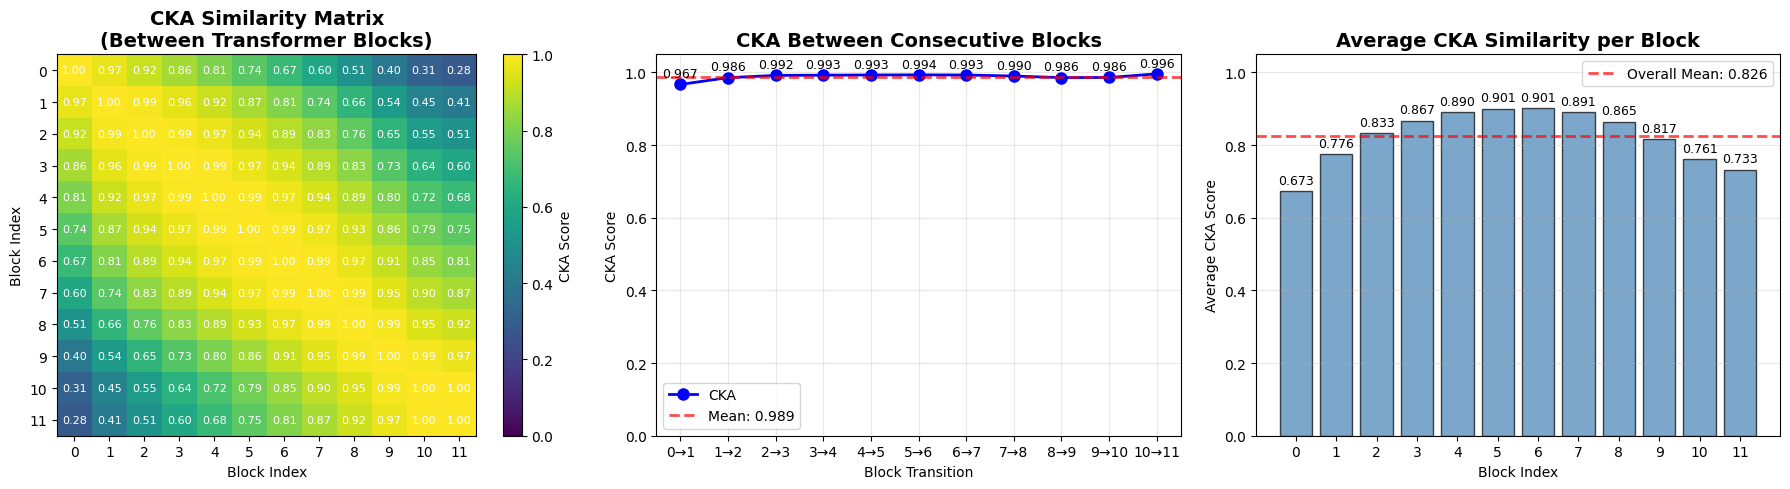


Analysis complete!

Interpretation Guide:
• High CKA (>0.8) between consecutive blocks:
  → Blocks learning very similar representations (potential redundancy)

• Medium CKA (0.5-0.8) between consecutive blocks:
  → Blocks refining representations while maintaining structure

• Low CKA (<0.5) between consecutive blocks:
  → Blocks learning distinct features (good differentiation)

• Decreasing CKA trend (early→late layers):
  → Hierarchical learning (basic → abstract features)

• Increasing CKA trend:
  → Representations converging to similar patterns


In [6]:
import torch
import torch.nn as nn
import os
import math
from contextlib import nullcontext
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from itertools import chain
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# Configuration
# ============================================================================
block_size = 128
batch_size = 8
eval_iters = 200

# ============================================================================
# CKA Implementation
# ============================================================================

class BatchwiseCKAComputer:
    """Compute CKA using streaming/batchwise updates."""
    def __init__(self, num_layers):
        self.num_layers = num_layers
        # Running sums for cross-covariance and self-covariance
        self.cross_cov = {}
        self.self_cov = {}
        self.n_samples = 0
        
    def update_batch(self, hidden_states):
        """
        hidden_states: list of tensors [batch_size, seq_len, hidden_dim]
        Flatten to [batch_size * seq_len, hidden_dim] for CKA computation
        """
        batch_size = hidden_states[0].shape[0]
        seq_len = hidden_states[0].shape[1]
        n = batch_size * seq_len
        
        # Flatten each layer's hidden states
        flattened = []
        for h in hidden_states:
            flattened.append(h.reshape(-1, h.shape[-1]))  # [n, d]
        
        # Update cross-covariance and self-covariance matrices
        for i in range(self.num_layers):
            for j in range(i, self.num_layers):
                key = (i, j)
                X = flattened[i]  # [n, d_i]
                Y = flattened[j]  # [n, d_j]
                
                # Compute gram matrices: K = X @ X.T, L = Y @ Y.T
                K = X @ X.T  # [n, n]
                L = Y @ Y.T  # [n, n]
                
                # HSIC = trace(K @ L)
                cross_hsic = torch.trace(K @ L).item()
                
                if key not in self.cross_cov:
                    self.cross_cov[key] = 0.0
                self.cross_cov[key] += cross_hsic
                
                # Self-covariance (for normalization)
                if i == j:
                    self_hsic = torch.trace(K @ K).item()
                    if i not in self.self_cov:
                        self.self_cov[i] = 0.0
                    self.self_cov[i] += self_hsic
        
        self.n_samples += n
    
    def compute_cka(self, i, j):
        """Compute CKA between layer i and j."""
        key = (min(i, j), max(i, j))
        if key not in self.cross_cov:
            return 0.0
        
        numerator = self.cross_cov[key]
        denominator = math.sqrt(self.self_cov[i] * self.self_cov[j])
        
        if denominator == 0:
            return 0.0
        
        return numerator / denominator
    
    def get_cka_matrix(self):
        """Return full CKA similarity matrix."""
        matrix = torch.zeros(self.num_layers, self.num_layers)
        for i in range(self.num_layers):
            for j in range(self.num_layers):
                matrix[i, j] = self.compute_cka(i, j)
        return matrix


# ============================================================================
# Data Loading
# ============================================================================

# Poor man's data loader
dataset = '/kaggle/input/wikitext/wikitext103'
data_dir = os.path.join('data', dataset)

def get_batch(split, device, device_type):
    """Load a batch of data from memmap files."""
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    
    if device_type == 'cuda':
        # Pin arrays x,y, which allows us to move them to GPU asynchronously
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    
    return x, y


# ============================================================================
# Model Loading and CKA Computation
# ============================================================================

# Model loading parameters
init_from = 'resume'
out_dir = './'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'

# Set device and dtype
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
device_type = 'cuda' if 'cuda' in device else 'cpu'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# # Load model
print(f"Loading model from {out_dir}...")
ckpt_path = '/kaggle/working/ckpt_layer_drop_best.pt' #'/kaggle/working/ckpt_best_learnable_scaling.pt' #'/kaggle/input/gpt-rezero/pytorch/default/1/ckpt_best.pt'
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])

model = GPT(gptconf)


# # model init
# model_args = dict(n_layer=12, n_head=12, n_embd=768, block_size=128,
#                   bias=False, vocab_size=50304, dropout=0.1) # start with model_args from command line
# gptconf = GPTConfig(**model_args)
# model = GPT(gptconf)


state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'
for k, v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

# Get model architecture info
num_blocks = model.config.n_layer  # Number of transformer blocks
hidden_size = model.config.n_embd
print(f"Model loaded: {num_blocks} transformer blocks, {hidden_size} hidden size")
print(f"Block size: {block_size}, Batch size: {batch_size}")
print(f"Will compute CKA for {num_blocks-1} consecutive block pairs")

# Initialize CKA computer for transformer blocks
cka_computer = BatchwiseCKAComputer(num_blocks)

# Process batches
print(f"\n{'='*70}")
print("Processing batches and computing CKA statistics...")
print(f"Collecting representations from {num_blocks} transformer blocks...")
print(f"Processing {eval_iters} iterations...")
print(f"{'='*70}\n")

total_loss = 0
total_tokens = 0

for k in tqdm(range(eval_iters), desc="Computing CKA"):
    X, Y = get_batch('train', device, device_type)
    
    with torch.no_grad():
        # Forward pass - collect hidden states after each block
        block_outputs = []
        x = X
        labels = Y
        
        # Get embedding (but don't include in CKA computation)
        tok_emb = model.transformer.wte(x)
        pos = torch.arange(0, x.size(1), dtype=torch.long, device=device)
        pos_emb = model.transformer.wpe(pos)
        x = model.transformer.drop(tok_emb + pos_emb)
        
        # Pass through transformer blocks and collect output after each block
        for block_idx, block in enumerate(model.transformer.h):
            x = block(x)
            # Store the output of this block on CPU to save GPU memory
            block_outputs.append(x.cpu())
        
        # Compute loss (no final LayerNorm in your model)
        logits = model.lm_head(x)
        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            labels.view(-1)
        )
        
        total_loss += loss.item() * x.numel()
        total_tokens += x.numel()
        
        # Update CKA statistics with block outputs
        cka_computer.update_batch(block_outputs)

# ============================================================================
# Results and Visualization
# ============================================================================

# Compute final results
print(f"\n{'='*70}")
print(f"Processed {eval_iters} batches with {cka_computer.n_samples} total samples")
print(f"Total tokens processed: {total_tokens}")

# Compute perplexity
average_loss = total_loss / total_tokens
perplexity = math.exp(average_loss)
print(f"Average loss: {average_loss:.4f}")
print(f"Perplexity on WikiText-103: {perplexity:.4f}")

# Get CKA results between consecutive blocks
print(f"\n{'='*70}")
print(f"CKA Scores (consecutive transformer blocks):")
print(f"{'='*70}")
cka_scores = []
for i in range(num_blocks - 1):
    cka_score = cka_computer.compute_cka(i, i + 1)
    cka_scores.append(cka_score)
    print(f"Block {i} → Block {i+1}: {cka_score:.4f}")

# Get full CKA matrix
cka_matrix = cka_computer.get_cka_matrix()

# Print some additional statistics
print(f"\n{'='*70}")
print("Additional CKA Statistics:")
print(f"{'='*70}")
print(f"Average consecutive block CKA: {np.mean(cka_scores):.4f}")
print(f"Min consecutive block CKA: {np.min(cka_scores):.4f}")
print(f"Max consecutive block CKA: {np.max(cka_scores):.4f}")
print(f"Std consecutive block CKA: {np.std(cka_scores):.4f}")

# Check similarity between first and last block
first_last_cka = cka_computer.compute_cka(0, num_blocks - 1)
print(f"\nFirst-to-Last block CKA (Block 0 → Block {num_blocks-1}): {first_last_cka:.4f}")

# Additional interesting comparisons
print(f"\n{'='*70}")
print("Additional Block Comparisons:")
print(f"{'='*70}")
if num_blocks >= 3:
    print(f"Block 0 → Block 2: {cka_computer.compute_cka(0, 2):.4f}")
if num_blocks >= 4:
    print(f"Block 0 → Block 3: {cka_computer.compute_cka(0, 3):.4f}")
if num_blocks >= 6:
    print(f"Block 1 → Block 5: {cka_computer.compute_cka(1, 5):.4f}")
    print(f"Block 2 → Block 5: {cka_computer.compute_cka(2, 5):.4f}")

# Plotting
print(f"\n{'='*70}")
print("Generating visualizations...")
print(f"{'='*70}\n")

fig = plt.figure(figsize=(18, 5))

# Plot 1: CKA Matrix
ax1 = plt.subplot(1, 3, 1)
im1 = ax1.imshow(cka_matrix.numpy(), cmap='viridis', aspect='auto', vmin=0, vmax=1)
cbar1 = plt.colorbar(im1, ax=ax1, label='CKA Score')
ax1.set_title("CKA Similarity Matrix\n(Between Transformer Blocks)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Block Index")
ax1.set_ylabel("Block Index")
ax1.set_xticks(range(num_blocks))
ax1.set_yticks(range(num_blocks))

# Add text annotations to the heatmap
for i in range(num_blocks):
    for j in range(num_blocks):
        text = ax1.text(j, i, f'{cka_matrix[i, j].item():.2f}',
                       ha="center", va="center", color="white", fontsize=8)

# Plot 2: Consecutive block comparisons
ax2 = plt.subplot(1, 3, 2)
block_pairs = [f"{i}→{i+1}" for i in range(len(cka_scores))]
x_pos = range(len(cka_scores))

ax2.plot(x_pos, cka_scores, 'b-o', label='CKA', linewidth=2, markersize=8)
ax2.axhline(y=np.mean(cka_scores), color='r', linestyle='--', 
            label=f'Mean: {np.mean(cka_scores):.3f}', alpha=0.7, linewidth=2)
ax2.set_title("CKA Between Consecutive Blocks", fontsize=14, fontweight='bold')
ax2.set_xlabel("Block Transition")
ax2.set_ylabel("CKA Score")
ax2.legend(fontsize=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(block_pairs, rotation=0, ha='center')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

# Add value labels on the points
for i, score in enumerate(cka_scores):
    ax2.text(i, score + 0.02, f'{score:.3f}', ha='center', fontsize=9)

# Plot 3: Layer-wise average similarity
ax3 = plt.subplot(1, 3, 3)
avg_similarity = cka_matrix.mean(dim=1).numpy()
bars = ax3.bar(range(num_blocks), avg_similarity, color='steelblue', alpha=0.7, edgecolor='black')
ax3.axhline(y=np.mean(avg_similarity), color='r', linestyle='--', 
            label=f'Overall Mean: {np.mean(avg_similarity):.3f}', alpha=0.7, linewidth=2)
ax3.set_title("Average CKA Similarity per Block", fontsize=14, fontweight='bold')
ax3.set_xlabel("Block Index")
ax3.set_ylabel("Average CKA Score")
ax3.set_xticks(range(num_blocks))
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1.05])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, avg_similarity)):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
             f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('block_cka_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'block_cka_analysis.png'")
plt.show()

print(f"\n{'='*70}")
print("Analysis complete!")
print(f"{'='*70}")
print("\nInterpretation Guide:")
print("=" * 70)
print("• High CKA (>0.8) between consecutive blocks:")
print("  → Blocks learning very similar representations (potential redundancy)")
print("\n• Medium CKA (0.5-0.8) between consecutive blocks:")
print("  → Blocks refining representations while maintaining structure")
print("\n• Low CKA (<0.5) between consecutive blocks:")
print("  → Blocks learning distinct features (good differentiation)")
print("\n• Decreasing CKA trend (early→late layers):")
print("  → Hierarchical learning (basic → abstract features)")
print("\n• Increasing CKA trend:")
print("  → Representations converging to similar patterns")
print("=" * 70)

In [7]:
import torch
import torch.nn as nn
import copy
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================================
# Layer Removal Functions
# ============================================================================

def identify_redundant_layers(cka_scores, threshold=0.95):
    """
    Identify layers to remove based on CKA threshold.
    Returns indices of layers that should be removed (the second layer in high-CKA pairs).
    
    Args:
        cka_scores: list of CKA scores between consecutive blocks
        threshold: CKA threshold above which layers are considered redundant
    
    Returns:
        list of layer indices to remove
    """
    layers_to_remove = []
    for i, score in enumerate(cka_scores):
        if score >= threshold:
            # Remove the second layer in the pair (i+1)
            layers_to_remove.append(i + 1)
    
    return sorted(list(set(layers_to_remove)))


def remove_layers_from_model(model, layers_to_remove):
    """
    Create a new model with specified layers removed.
    
    Args:
        model: original GPT model
        layers_to_remove: list of block indices to remove
    
    Returns:
        new model with layers removed
    """
    # Create a deep copy of the model
    new_model = copy.deepcopy(model)
    
    # Get the original blocks
    original_blocks = list(new_model.transformer.h)
    
    # Create new block list without the removed layers
    new_blocks = [block for i, block in enumerate(original_blocks) 
                  if i not in layers_to_remove]
    
    # Replace the module list
    new_model.transformer.h = nn.ModuleList(new_blocks)
    
    # Update config
    new_model.config.n_layer = len(new_blocks)
    
    return new_model


def evaluate_perplexity(model, device, device_type, ctx, eval_iters=200):
    """
    Evaluate perplexity on validation set.
    
    Args:
        model: model to evaluate
        device: device to run on
        device_type: 'cuda' or 'cpu'
        ctx: autocast context
        eval_iters: number of evaluation iterations
    
    Returns:
        perplexity, average_loss
    """
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for k in tqdm(range(eval_iters), desc="Evaluating", leave=False):
            X, Y = get_batch('val', device, device_type)
            
            with ctx:
                # Forward pass
                tok_emb = model.transformer.wte(X)
                pos = torch.arange(0, X.size(1), dtype=torch.long, device=device)
                pos_emb = model.transformer.wpe(pos)
                x = model.transformer.drop(tok_emb + pos_emb)
                
                # Pass through remaining blocks
                for block in model.transformer.h:
                    x = block(x)
                
                # Compute loss
                logits = model.lm_head(x)
                loss = nn.functional.cross_entropy(
                    logits.view(-1, logits.size(-1)), 
                    Y.view(-1)
                )
                
                total_loss += loss.item() * X.numel()
                total_tokens += X.numel()
    
    average_loss = total_loss / total_tokens
    perplexity = np.exp(average_loss)
    
    return perplexity, average_loss


# ============================================================================
# Main Analysis: Remove Layers and Measure Degradation
# ============================================================================

print(f"\n{'='*80}")
print("LAYER REMOVAL ANALYSIS")
print(f"{'='*80}\n")

# Define different CKA thresholds to test
thresholds = [ 0.99]

# Store results
results = []

# Baseline: Evaluate original model
print("Evaluating baseline model (no layers removed)...")
baseline_perplexity, baseline_loss = evaluate_perplexity(
    model, device, device_type, ctx, eval_iters=eval_iters
)
print(f"✓ Baseline Perplexity: {baseline_perplexity:.4f}")
print(f"✓ Baseline Loss: {baseline_loss:.4f}")

results.append({
    'threshold': 'baseline',
    'layers_removed': [],
    'num_removed': 0,
    'remaining_layers': num_blocks,
    'perplexity': baseline_perplexity,
    'loss': baseline_loss,
    'perplexity_increase': 0.0,
    'relative_increase': 0.0
})

print(f"\n{'-'*80}\n")

# Test different thresholds
for threshold in thresholds:
    print(f"Testing CKA threshold: {threshold}")
    print(f"{'-'*80}")
    
    # Identify layers to remove
    layers_to_remove = identify_redundant_layers(cka_scores, threshold=threshold)
    #layers_to_remove = [3,4,5,6,7,8,9,10]
    if len(layers_to_remove) == 0:
        print(f"  No layers exceed CKA threshold of {threshold}")
        print()
        continue
    
    print(f"  Layers to remove: {layers_to_remove}")
    print(f"  Number of layers to remove: {len(layers_to_remove)}/{num_blocks}")
    
    # Create model with layers removed
    print(f"  Creating model with {len(layers_to_remove)} layers removed...")
    pruned_model = remove_layers_from_model(model, layers_to_remove)
    pruned_model = pruned_model.to(device)
    
    # Evaluate pruned model
    print(f"  Evaluating pruned model...")
    pruned_perplexity, pruned_loss = evaluate_perplexity(
        pruned_model, device, device_type, ctx, eval_iters=eval_iters
    )
    
    # Calculate degradation
    perplexity_increase = pruned_perplexity - baseline_perplexity
    relative_increase = (perplexity_increase / baseline_perplexity) * 100
    
    print(f"  ✓ Pruned Perplexity: {pruned_perplexity:.4f}")
    print(f"  ✓ Pruned Loss: {pruned_loss:.4f}")
    print(f"  ✓ Perplexity Increase: {perplexity_increase:.4f} ({relative_increase:.2f}%)")
    print()
    
    # Store results
    results.append({
        'threshold': threshold,
        'layers_removed': layers_to_remove,
        'num_removed': len(layers_to_remove),
        'remaining_layers': num_blocks - len(layers_to_remove),
        'perplexity': pruned_perplexity,
        'loss': pruned_loss,
        'perplexity_increase': perplexity_increase,
        'relative_increase': relative_increase
    })
    
    # Free memory
    del pruned_model
    torch.cuda.empty_cache()

# ============================================================================
# Results Summary
# ============================================================================

print(f"\n{'='*80}")
print("RESULTS SUMMARY")
print(f"{'='*80}\n")

# Create summary table
print(f"{'Threshold':<12} {'Removed':<10} {'Remaining':<12} {'Perplexity':<14} {'Increase':<14} {'Relative %':<12}")
print(f"{'-'*80}")

for result in results:
    threshold_str = 'Baseline' if result['threshold'] == 'baseline' else f"{result['threshold']:.2f}"
    print(f"{threshold_str:<12} {result['num_removed']:<10} {result['remaining_layers']:<12} "
          f"{result['perplexity']:<14.4f} {result['perplexity_increase']:<14.4f} {result['relative_increase']:<12.2f}")

print(f"{'-'*80}\n")




LAYER REMOVAL ANALYSIS

Evaluating baseline model (no layers removed)...


✓ Baseline Perplexity: 77.7458
✓ Baseline Loss: 4.3534

--------------------------------------------------------------------------------

Testing CKA threshold: 0.99
--------------------------------------------------------------------------------
  Layers to remove: [3, 4, 5, 6, 7, 8, 11]
  Number of layers to remove: 7/12
  Creating model with 7 layers removed...
  Evaluating pruned model...


  ✓ Pruned Perplexity: 108.1911
  ✓ Pruned Loss: 4.6839
  ✓ Perplexity Increase: 30.4453 (39.16%)


RESULTS SUMMARY

Threshold    Removed    Remaining    Perplexity     Increase       Relative %  
--------------------------------------------------------------------------------
Baseline     0          12           77.7458        0.0000         0.00        
0.99         7          5            108.1911       30.4453        39.16       
--------------------------------------------------------------------------------

